In [3]:
import tarfile
import os

archivo = "outputs3.tar.gz"

with tarfile.open(archivo, "r:gz") as tar:
    tar.extractall(os.path.dirname(archivo) or ".")

print("Listo.")

Listo.


In [4]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# El notebook debe abrirse con la raiz del repositorio como directorio de trabajo.
REPO_ROOT = Path.cwd()
OUTPUTS_DIR = REPO_ROOT / "outputs"
CHECKPOINTS_DIR = OUTPUTS_DIR / "checkpoints"
H4_CHECKPOINTS_DIR = CHECKPOINTS_DIR / "h4"
TENSORBOARD_DIR = OUTPUTS_DIR / "tensorboard"
RESULTS_DIR = OUTPUTS_DIR / "results"
CSV_PATH = RESULTS_DIR / "h4_results.csv"


print(f"outputs/: {OUTPUTS_DIR.exists()}")
print(f"CSV de resultados: {CSV_PATH.exists()}")

outputs/: True
CSV de resultados: True


In [5]:
# Descubrimiento de archivos
paths_to_check = {
    "outputs/checkpoints/": CHECKPOINTS_DIR,
    "outputs/checkpoints/h4/": H4_CHECKPOINTS_DIR,
    "outputs/tensorboard/": TENSORBOARD_DIR,
    "outputs/results/": RESULTS_DIR,
    "outputs/results/h4_results.csv": CSV_PATH,
}
for label, path in paths_to_check.items():
    print(f"{label:<36} {'OK' if path.exists() else 'NO EXISTE'}")

checkpoint_files = sorted(CHECKPOINTS_DIR.rglob("*.pt")) if CHECKPOINTS_DIR.exists() else []
event_files = sorted(TENSORBOARD_DIR.rglob("*.tfevents.*")) if TENSORBOARD_DIR.exists() else []
result_files = sorted(RESULTS_DIR.glob("*.csv")) if RESULTS_DIR.exists() else []
print(f"\nCheckpoints .pt encontrados: {len(checkpoint_files)}")
print(f"Eventos TensorBoard encontrados: {len(event_files)}")
print(f"CSV encontrados en resultados: {len(result_files)}")
if not CSV_PATH.exists():
    print("ADVERTENCIA: falta h4_results.csv. Ejecuta primero:")
    print("docker compose run --rm python-agent `")
    print("  uv run python main.py `")
    print("  --config configs/h4_native_precision.yaml")

outputs/checkpoints/                 OK
outputs/checkpoints/h4/              OK
outputs/tensorboard/                 OK
outputs/results/                     OK
outputs/results/h4_results.csv       OK

Checkpoints .pt encontrados: 32
Eventos TensorBoard encontrados: 16
CSV encontrados en resultados: 1


# Carga y descripción del CSV

`h4_results.csv` es la fuente principal para comparar configuraciones. Esta sección no modifica los valores originales: limpia nombres, convierte las columnas analíticas a numérico y muestra la evidencia descriptiva antes de calcular rankings.

Configuraciones ejecutadas: 16
Filas y columnas: (16, 34)
Columnas disponibles: 34


,column,dtype
0,experiment_id,object
1,precision,object
2,bits,int64
3,hidden_size,int64
4,n_hidden_layers,int64
5,episodes_trained,int64
6,stopped_early,bool
7,best_episode,int64
8,best_mean_reward,float64
9,best_eval_reward,float64


Valores faltantes por columna:


,missing
experiment_id,0
precision,0
bits,0
hidden_size,0
n_hidden_layers,0
episodes_trained,0
stopped_early,0
best_episode,0
best_mean_reward,0
best_eval_reward,0


Resumen estadístico de variables numéricas:


...

,device,count
0,cuda,8
1,cpu,8


hidden_size:


,hidden_size,count
0,16,4
1,32,4
2,64,4
3,128,4


Valores no finitos en métricas numéricas:


,finite,non_finite
bits,16,0
hidden_size,16,0
episodes_trained,16,0
best_mean_reward,16,0
best_eval_reward,16,0
eval_mean_reward,16,0
eval_makespan,16,0
eval_sla_violations,16,0
eval_sla_rate,16,0
latency_mean_ms,16,0


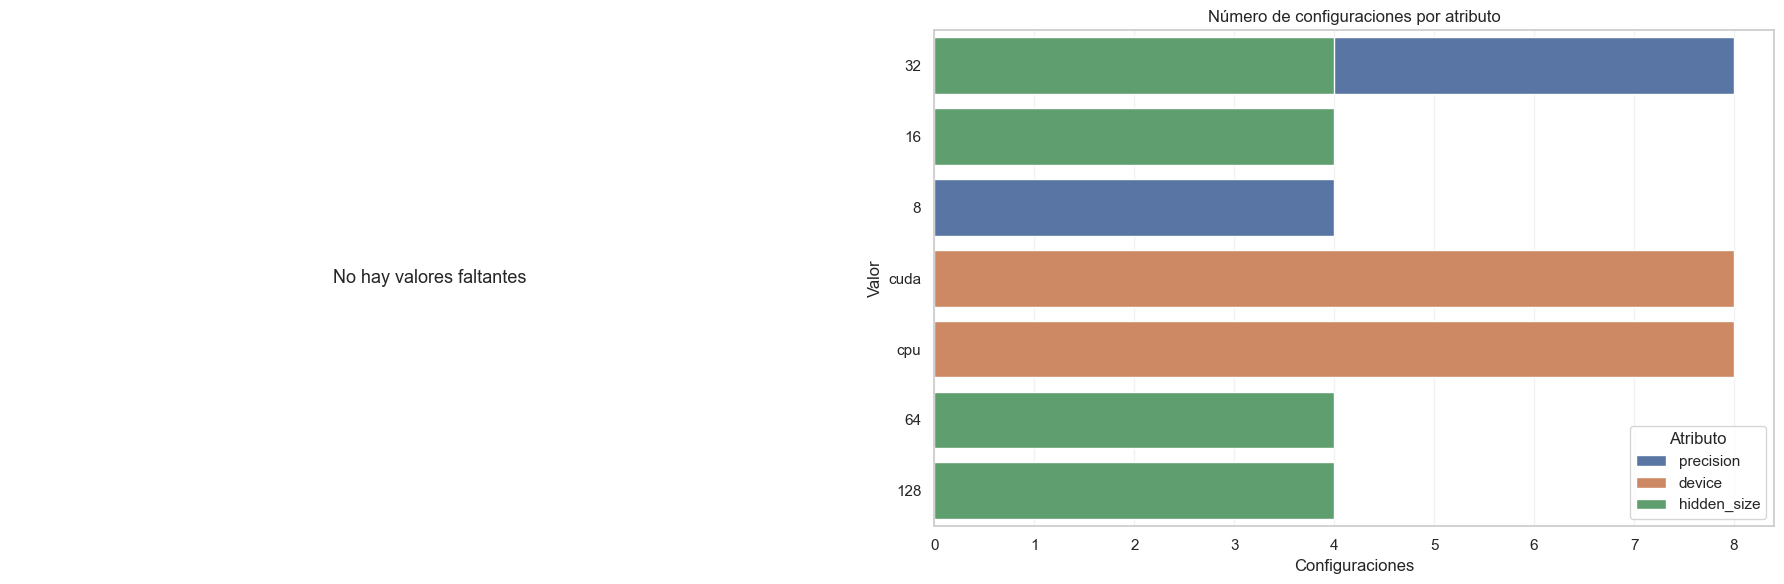

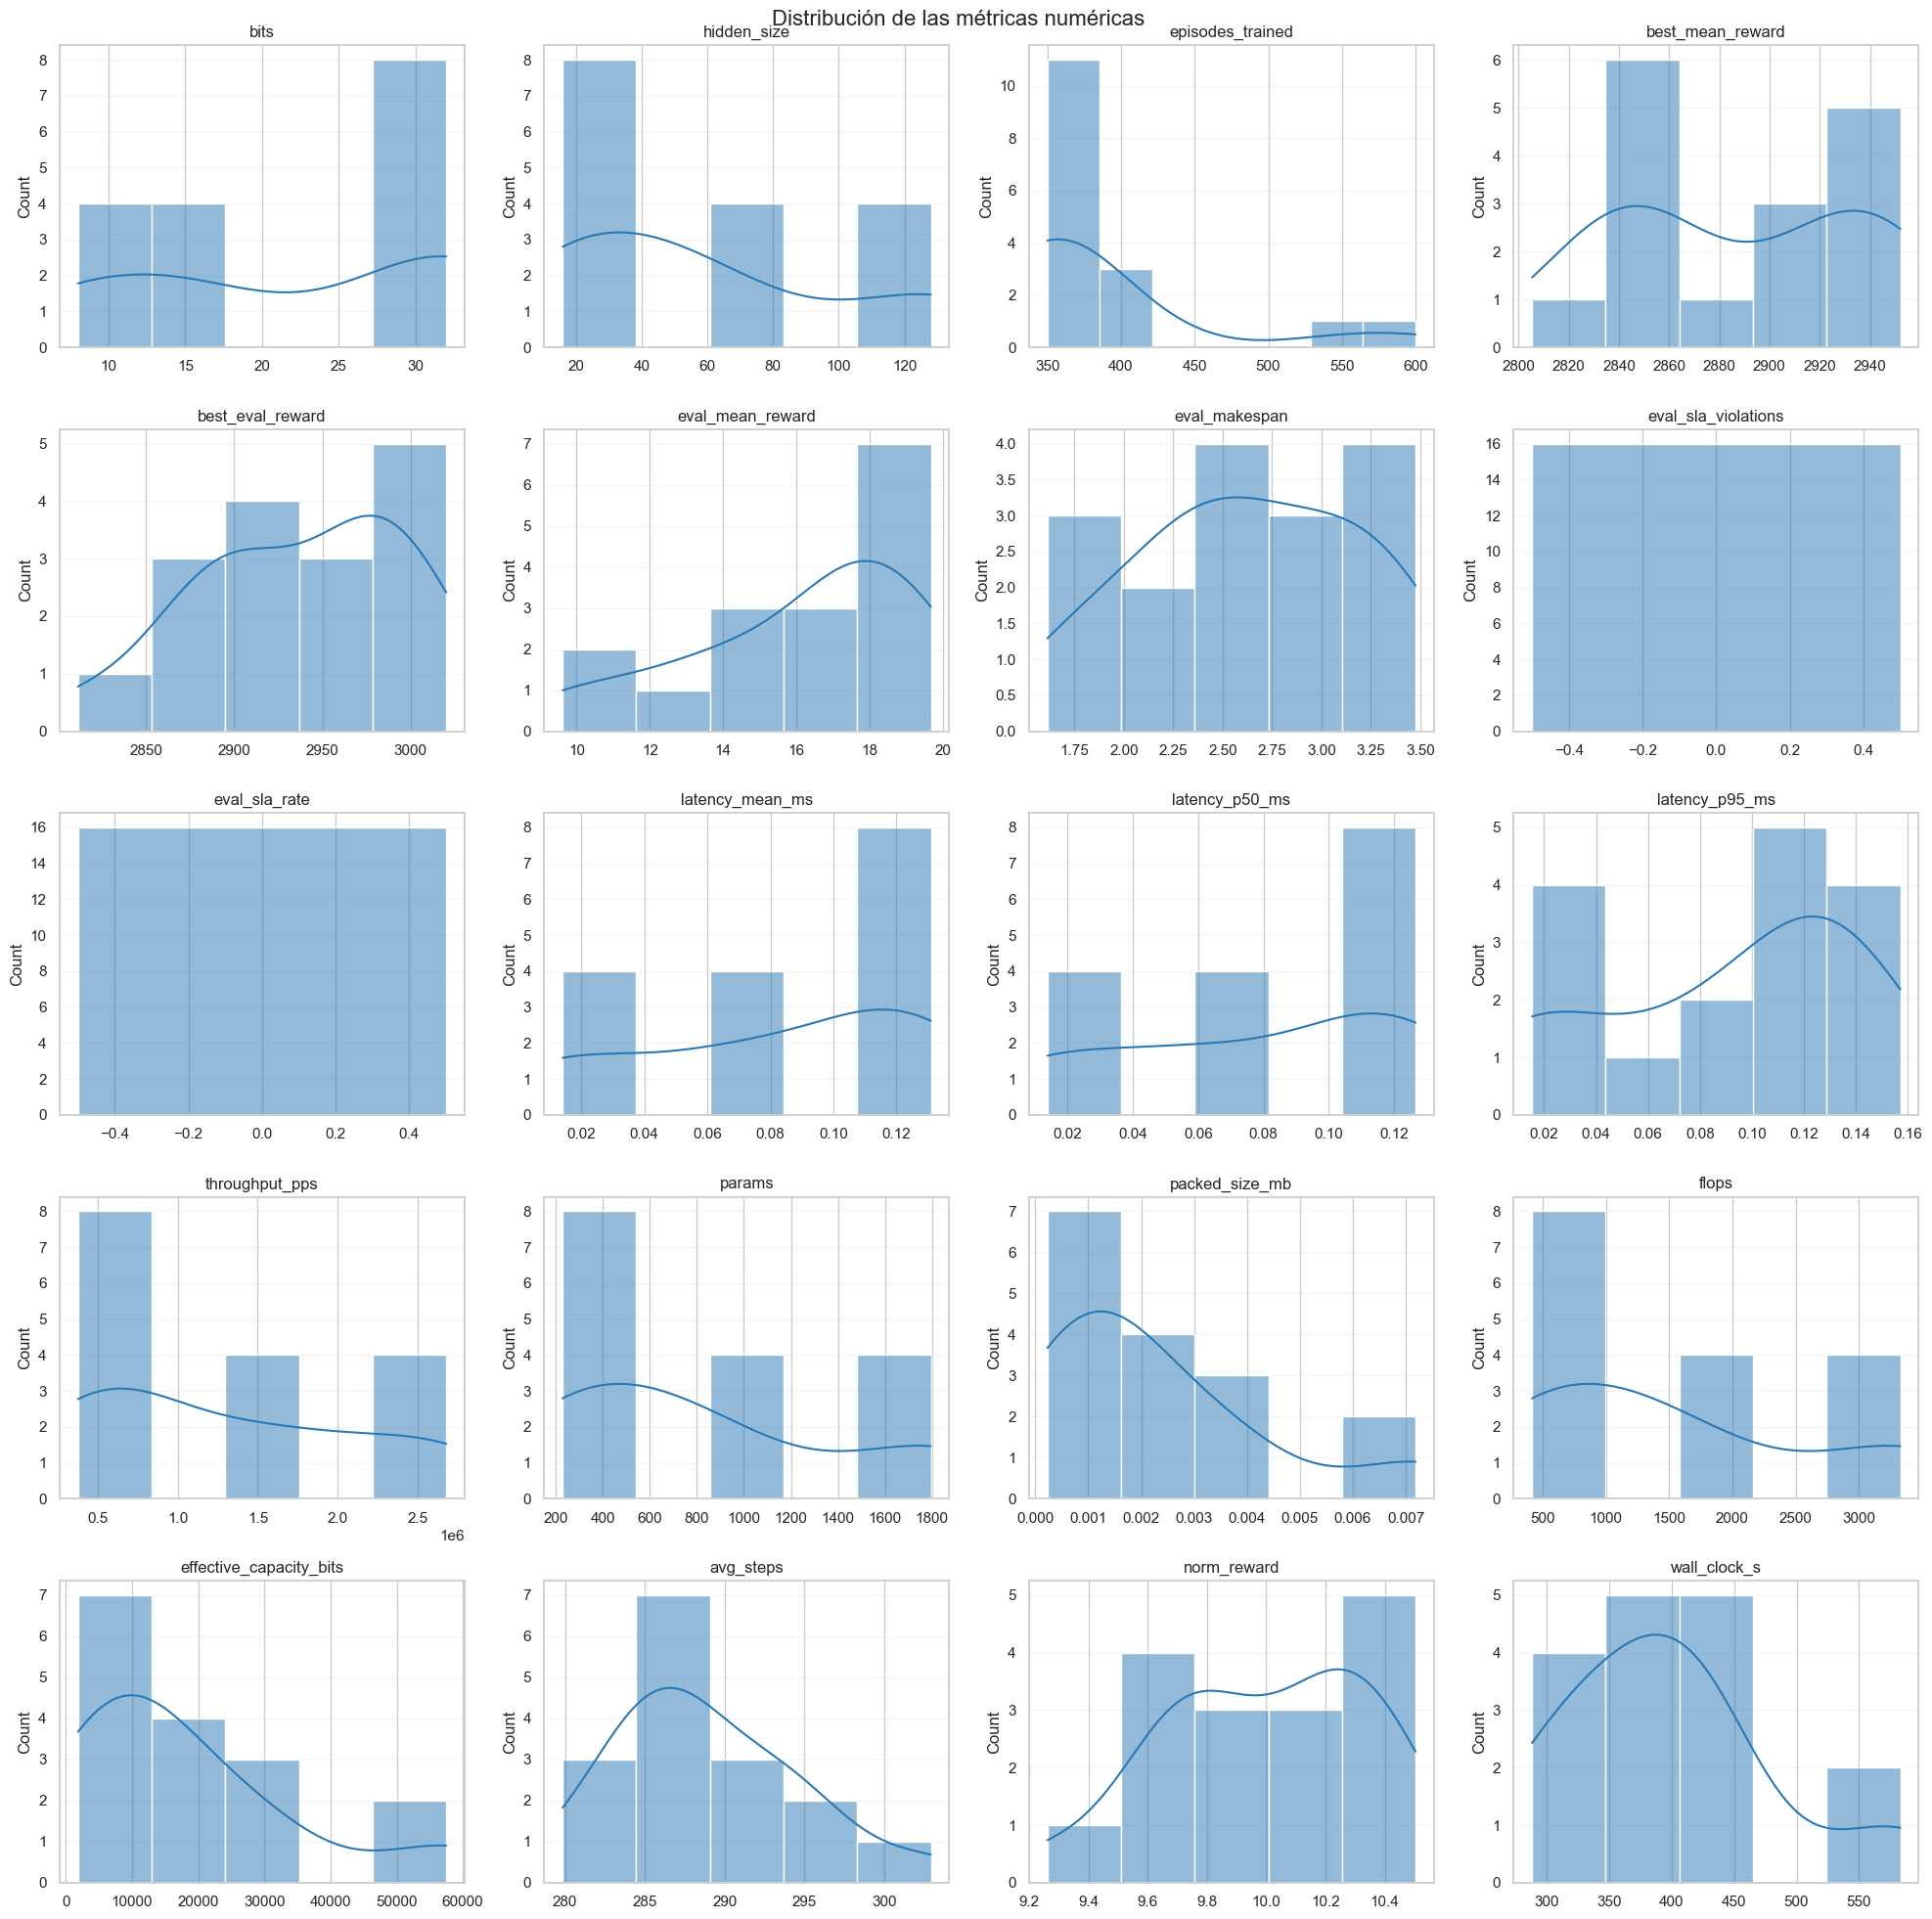

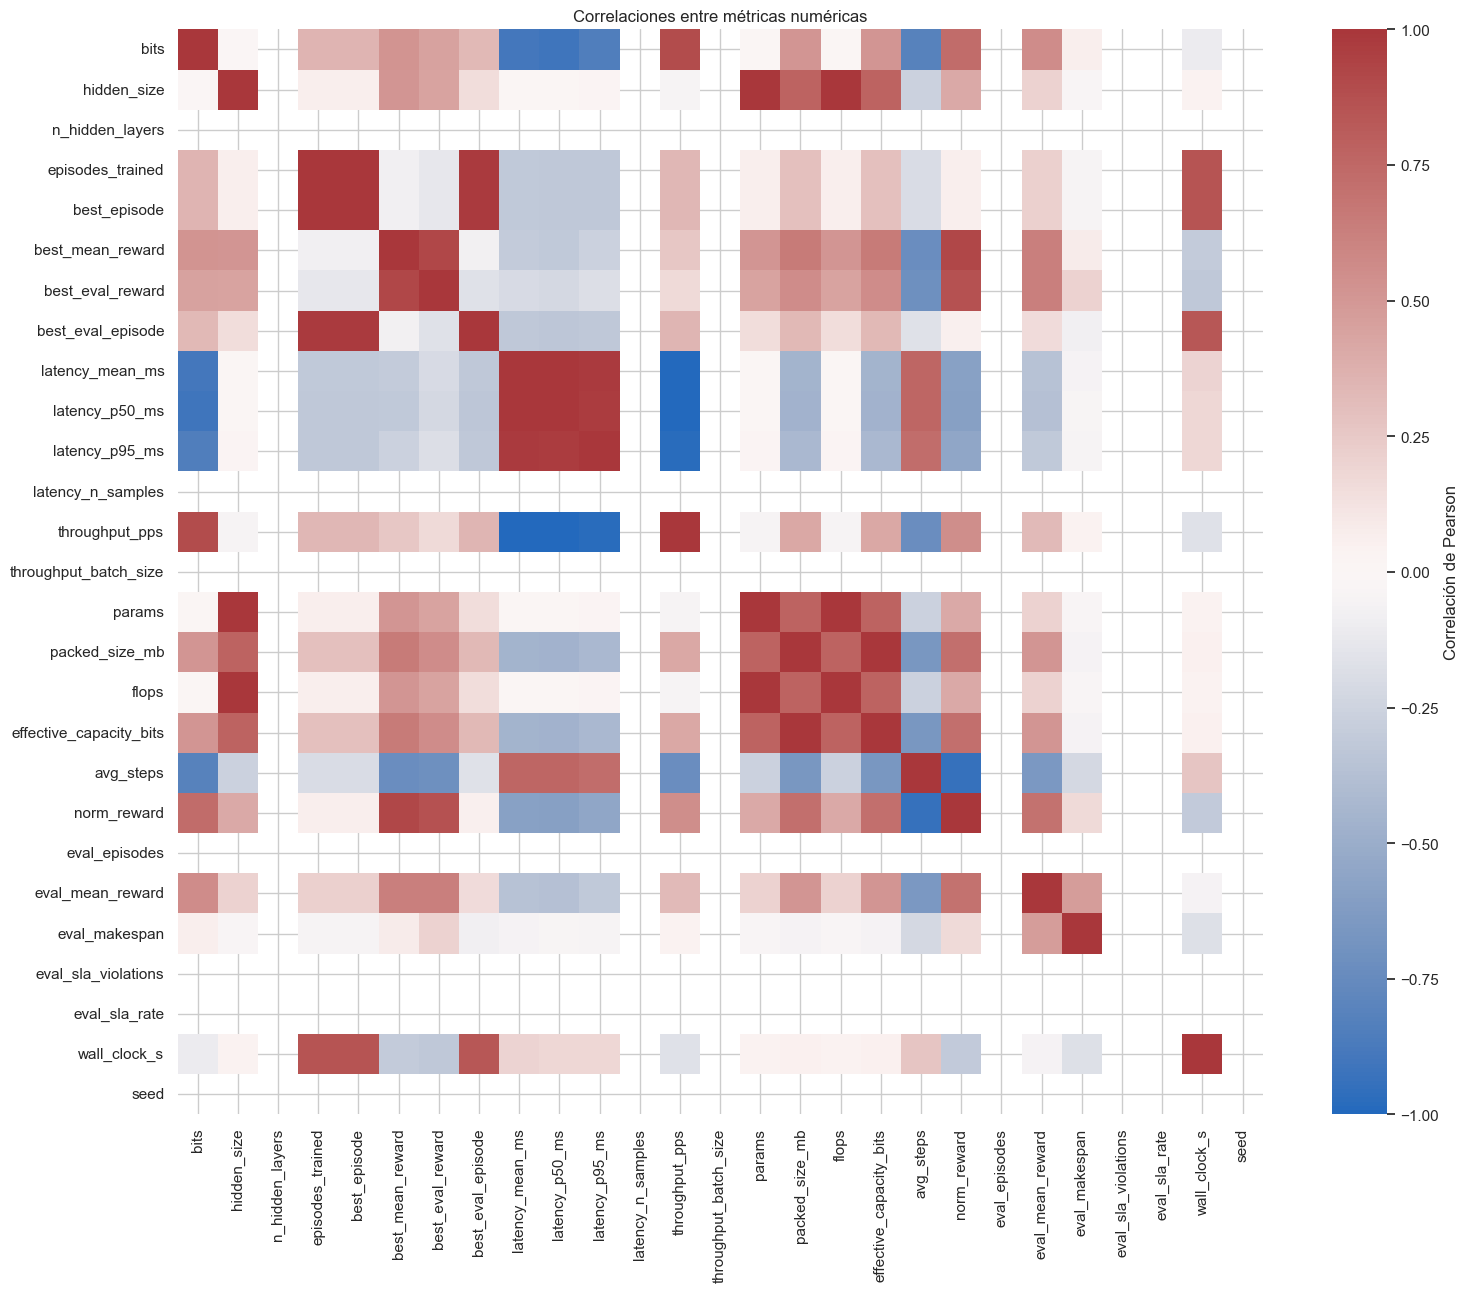

In [6]:
# Carga, limpieza y descripción del CSV
numeric_columns = [
    "bits", "hidden_size", "episodes_trained", "best_mean_reward", "best_eval_reward",
    "eval_mean_reward", "eval_makespan", "eval_sla_violations", "eval_sla_rate",
    "latency_mean_ms", "latency_p50_ms", "latency_p95_ms", "throughput_pps", "params",
    "packed_size_mb", "flops", "effective_capacity_bits", "avg_steps", "norm_reward",
    "wall_clock_s",
]

if CSV_PATH.exists():
    results = pd.read_csv(CSV_PATH, skipinitialspace=True)
    results.columns = results.columns.str.strip()
    for column in numeric_columns:
        if column in results.columns:
            results[column] = pd.to_numeric(results[column], errors="coerce")
    for column in ("precision", "device", "experiment_id"):
        if column in results.columns:
            results[column] = results[column].astype(str).str.strip()
    results["config"] = results.apply(
        lambda row: " / ".join(str(row.get(key, "?")) for key in ("precision", "device", "hidden_size")),
        axis=1,
    )
else:
    results = pd.DataFrame()

if results.empty:
    print("No hay datos disponibles para describir. Revisa la ruta del CSV en la sección de descubrimiento.")
else:
    print(f"Configuraciones ejecutadas: {len(results)}")
    print(f"Filas y columnas: {results.shape}")
    print(f"Columnas disponibles: {len(results.columns)}")
    display(pd.DataFrame({"column": results.columns, "dtype": results.dtypes.astype(str).values}))

    print("Valores faltantes por columna:")
    missing = results.isna().sum().sort_values(ascending=False).rename("missing")
    display(missing.to_frame())

    print("Resumen estadístico de variables numéricas:")
    numeric_results = results.select_dtypes(include=np.number)
    descriptive_stats = numeric_results.describe().T
    display(descriptive_stats)

    print("Distribución de configuraciones:")
    for column in ("precision", "device", "hidden_size"):
        if column in results.columns:
            print(f"{column}:")
            display(results[column].value_counts(dropna=False).rename_axis(column).reset_index(name="count"))

    print("Valores no finitos en métricas numéricas:")
    finite_check = pd.DataFrame({
        column: [int(np.isfinite(results[column]).sum()), int((~np.isfinite(results[column])).sum())]
        for column in numeric_columns if column in results.columns
    }, index=["finite", "non_finite"]).T
    display(finite_check)

    # 1. Calidad del contenido: faltantes y cantidad de configuraciones por grupo.
    figure, axes = plt.subplots(1, 2, figsize=(18, 6))
    missing_to_plot = missing[missing > 0].sort_values()
    if missing_to_plot.empty:
        axes[0].text(0.5, 0.5, "No hay valores faltantes", ha="center", va="center", fontsize=13)
        axes[0].set_axis_off()
    else:
        missing_to_plot.plot.barh(ax=axes[0], color="#d95f02")
        axes[0].set_title("Valores faltantes por columna")
        axes[0].set_xlabel("Cantidad de valores faltantes")
        axes[0].grid(axis="x", alpha=0.25)

    group_counts = []
    for column in ("precision", "device", "hidden_size"):
        if column in results.columns:
            counts = results[column].value_counts().rename_axis("value").reset_index(name="count")
            counts["group"] = column
            group_counts.append(counts)
    if group_counts:
        group_counts_frame = pd.concat(group_counts, ignore_index=True)
        sns.barplot(data=group_counts_frame, x="count", y="value", hue="group", ax=axes[1])
        axes[1].set_title("Número de configuraciones por atributo")
        axes[1].set_xlabel("Configuraciones")
        axes[1].set_ylabel("Valor")
        axes[1].legend(title="Atributo")
        axes[1].grid(axis="x", alpha=0.25)
    figure.tight_layout()
    plt.show()

    # 2. Distribuciones de las métricas numéricas, con una escala independiente por variable.
    plot_columns = [column for column in numeric_columns if column in numeric_results.columns]
    n_columns = 4
    n_rows = int(np.ceil(len(plot_columns) / n_columns))
    figure, axes = plt.subplots(n_rows, n_columns, figsize=(20, 4 * n_rows), squeeze=False)
    for axis, column in zip(axes.flat, plot_columns):
        sns.histplot(results[column].dropna(), kde=True, ax=axis, color="#2878b5")
        axis.set_title(column)
        axis.set_xlabel("")
        axis.grid(axis="y", alpha=0.2)
    for axis in axes.flat[len(plot_columns):]:
        axis.set_visible(False)
    figure.suptitle("Distribución de las métricas numéricas", fontsize=16)
    figure.tight_layout()
    plt.show()

    # 3. Correlaciones lineales entre métricas numéricas.
    correlation = numeric_results.corr(numeric_only=True)
    figure, axis = plt.subplots(figsize=(16, 13))
    sns.heatmap(
        correlation,
        ax=axis,
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        annot=False,
        square=True,
        cbar_kws={"label": "Correlación de Pearson"},
    )
    axis.set_title("Correlaciones entre métricas numéricas")
    figure.tight_layout()
    plt.show()



# Cálculo de Métricas

## 1. Reward promedio de evaluación

$$
\text{eval\_mean\_reward}
=
\frac{1}{N}
\sum_{i=1}^{N} R_i
$$

Donde:

- $N$: número de episodios de evaluación.
- $R_i$: reward total del episodio $i$.

Objetivo: **maximizar**.

---

## 2. Violaciones SLA

Una tarea viola SLA cuando termina después de su deadline:

$$
\text{SLA violation}_j =
\begin{cases}
1, & \text{si } finish_j > deadline_j \\
0, & \text{si } finish_j \leq deadline_j
\end{cases}
$$

El total es:

$$
\text{eval\_sla\_violations}
=
\sum_{j=1}^{M}
\text{SLA violation}_j
$$

Donde $M$ es el número total de Cloudlets.

Objetivo: **minimizar**.

---

## 3. Tasa de violaciones SLA

$$
\text{eval\_sla\_rate}
=
\frac{\text{eval\_sla\_violations}}
{\text{total Cloudlets}}
$$

Como porcentaje:

$$
\text{SLA rate (\%)}
=
100 \times
\frac{\text{eval\_sla\_violations}}
{\text{total Cloudlets}}
$$

Objetivo: **minimizar**.

---

## 4. Makespan

El makespan es el tiempo de finalización de la última tarea:

$$
\text{eval\_makespan}
=
\max_j(finish_j)
-
\min_j(submission_j)
$$

Donde:

- $finish_j$: tiempo de finalización del Cloudlet $j$.
- $submission_j$: tiempo de llegada del Cloudlet $j$.

Objetivo: **minimizar**.

---

## 5. Latencia media

$$
\text{latency\_mean\_ms}
=
\frac{1}{N}
\sum_{i=1}^{N} t_i
$$

Donde $t_i$ es el tiempo del forward pass de la red neuronal para la muestra $i$.

Objetivo: **minimizar**.

---

## 6. Latencia p50

La latencia p50 es la mediana:

$$
\text{latency\_p50\_ms}
=
P_{50}(t_1, t_2, \dots, t_N)
$$

El 50% de las inferencias tarda menos o igual que este valor.

Objetivo: **minimizar**.

---

## 7. Latencia p95

$$
\text{latency\_p95\_ms}
=
P_{95}(t_1, t_2, \dots, t_N)
$$

El 95% de las inferencias termina antes o igual que este tiempo.

Objetivo: **minimizar**.

---

## 8. Throughput

$$
\text{throughput\_pps}
=
\frac{\text{batch\_size} \times \text{n\_batches}}
{\text{elapsed\_time}}
$$

Donde:

- `batch_size`: muestras procesadas por batch.
- `n_batches`: número de batches.
- `elapsed_time`: tiempo total en segundos.

Unidad:

```text
samples/second

## Tamaño empaquetado: `packed_size_mb`

`packed_size_mb` estima cuánto espacio ocupan los pesos del modelo según el número de parámetros y la precisión utilizada.

La fórmula es:

$$
\text{packed\_size\_mb}
=
\frac{\text{params} \times \text{bits}}
{8 \times 1024^2}
$$

Donde:

- `params`: número total de parámetros.
- `bits`: cantidad de bits utilizados por parámetro.
- `8`: conversión de bits a bytes.
- `1024^2`: conversión de bytes a megabytes.

### Ejemplo conceptual

Para un modelo con 1,000,000 de parámetros:

#### FP32

$$
\text{packed\_size\_mb}
=
\frac{1{,}000{,}000 \times 32}
{8 \times 1024^2}
\approx 3.81 \text{ MB}
$$

#### FP16

$$
\text{packed\_size\_mb}
=
\frac{1{,}000{,}000 \times 16}
{8 \times 1024^2}
\approx 1.91 \text{ MB}
$$

#### INT8

$$
\text{packed\_size\_mb}
=
\frac{1{,}000{,}000 \times 8}
{8 \times 1024^2}
\approx 0.95 \text{ MB}
$$

### Interpretación

Un valor menor de `packed_size_mb` implica:

- menor uso de memoria;
- menor almacenamiento requerido;
- mejor posibilidad de desplegar el modelo en dispositivos edge;
- menor coste de transferencia del modelo.

Esta métrica se debe **minimizar**, siempre que la calidad del agente no disminuya demasiado.

En el proyecto se guarda mediante:

```python
packed_size_mb = packed_size_mb(params, precision_name)

## FLOPs: `flops`

`flops` estima la cantidad de operaciones de coma flotante necesarias para realizar una inferencia de la red neuronal.

Primero se calculan las operaciones MAC:

$$
\text{MACs}
=
D \times H
+
(L-1) \times H^2
+
H \times A
$$

Donde:

- `D`: dimensión del estado de entrada;
- `H`: tamaño de la capa oculta (`hidden_size`);
- `L`: número de capas ocultas;
- `A`: número de acciones posibles.

Después se estima que cada MAC contiene una multiplicación y una suma:

$$
\text{FLOPs}
=
2 \times \text{MACs}
$$

### Ejemplo conceptual

Supongamos:

- $D = 3$
- $H = 256$
- $L = 2$
- $A = 19$

Primero:

$$
\text{MACs}
=
(3 \times 256)
+
(2-1) \times 256^2
+
(256 \times 19)
$$

$$
\text{MACs}
=
768
+
65{,}536
+
4{,}864
$$

$$
\text{MACs}
=
71{,}168
$$

Entonces:

$$
\text{FLOPs}
=
2 \times 71{,}168
=
142{,}336
$$

### Interpretación

Un valor menor de `flops` implica:

- menor trabajo computacional teórico;
- menor coste potencial de inferencia;
- menor consumo de recursos;
- posibilidad de menor latencia.

Esta métrica se debe **minimizar**, pero no sustituye la medición real de latencia.

Una red con menos FLOPs no siempre es más rápida, porque el resultado también depende de:

- CPU o GPU;
- librerías utilizadas;
- kernel matemático;
- tamaño del batch;
- optimizaciones del hardware;
- transferencia de memoria.

En el proyecto se obtiene mediante:

### `eval_makespan`
## Makespan de evaluación: `eval_makespan`

`eval_makespan` representa el tiempo promedio que necesita el sistema para completar todos los Cloudlets de los episodios de evaluación.

Para cada episodio se calcula el makespan como la diferencia entre el momento de finalización del último Cloudlet y el momento de llegada del primer Cloudlet:

$$
M_i =
\max_j(\text{finish}_{i,j})
-
\min_j(\text{submission}_{i,j})
$$

Donde:

- $M_i$: makespan del episodio $i$;
- $\text{finish}_{i,j}$: tiempo de finalización del Cloudlet $j$ en el episodio $i$;
- $\text{submission}_{i,j}$: tiempo de llegada del Cloudlet $j$ en el episodio $i$.

Después se calcula el promedio del makespan entre todos los episodios *held-out*:

$$
\text{eval\_makespan}
=
\frac{1}{N}
\sum_{i=1}^{N} M_i
$$

Donde:

- $N$: número de episodios de evaluación;
- $M_i$: makespan correspondiente al episodio $i$.
El `eval_makespan` corresponde al tiempo total necesario para completar el workload. En este caso:

$$
\text{eval\_makespan}
=
312.0 + 10.0 + 14.0
=
336.0\ \text{segundos}
$$

Por lo tanto:

```text
eval_makespan = 336.0 segundos

# Metodología matemática

## 1. Métricas observadas y métricas derivadas

Las columnas de evaluación, como `eval_mean_reward`, `eval_makespan`, `eval_sla_rate`, `latency_p95_ms` y `throughput_pps`, 
Para una configuración $i$ se usa el vector observado:

$$
\mathbf{x}_i = (
R_i, A_i, M_i, L_i, T_i, B_i, F_i
)
$$

con:

- $R_i = \text{eval\_mean\_reward}$: reward held-out.
- $A_i = \text{eval\_sla\_rate}$: proporción de violaciones SLA.
- $M_i = \text{eval\_makespan}$: tiempo total del workload.
- $L_i = \text{latency\_p95\_ms}$: percentil 95 de latencia.
- $T_i = \text{throughput\_pps}$: elementos procesados por segundo.
- $B_i = \text{packed\_size\_mb}$: tamaño empaquetado.
- $F_i = \text{flops}$: operaciones estimadas.

## 2. Estadísticos descriptivos

Para una métrica $x$ con $n$ configuraciones, la media, varianza muestral y desviación estándar son:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

$$
 s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

$$
 s = \sqrt{s^2}
$$

La mediana es el percentil 50. Los cuartiles $Q_1$ y $Q_3$ dividen los datos en cuatro partes; el rango intercuartílico es:

$$
IQR = Q_3-Q_1
$$

`describe()` muestra estos estadísticos, además de mínimos, máximos y conteos válidos.

## 3. Ranking y agregación

El ranking principal ordena lexicográficamente por:

$$
\text{eval\_mean\_reward}\downarrow,
\quad \text{eval\_sla\_rate}\uparrow,
\quad \text{eval\_makespan}\uparrow
$$

Las tablas agrupadas calculan la media de cada métrica dentro de grupos de precisión, dispositivo y tamaño oculto:

$$
\bar{x}_{g} = \frac{1}{|g|}\sum_{i\in g}x_i
$$

## 4. Percentiles de latencia

El P95 es el valor $L_{0.95}$ que deja aproximadamente el 95% de las observaciones por debajo:

$$
P95 = \inf\{x: F_L(x) \geq 0.95\}
$$

donde $F_L$ es la función de distribución acumulada de las latencias. El P95 permite observar la cola alta y no solo el comportamiento medio.

## 5. Score multicriterio

Primero se transforma cada métrica a conveniencia $C_{ij}\in[0,1]$. Si mayor es mejor:

$$
C_{ij}=\frac{x_{ij}-x_j^{min}}{x_j^{max}-x_j^{min}}
$$

Si menor es mejor:

$$
C_{ij}=\frac{x_j^{max}-x_{ij}}{x_j^{max}-x_j^{min}}
$$

Si $x_j^{max}=x_j^{min}$, se asigna $C_{ij}=1$ para todo $i$: hay empate y esa métrica no discrimina.

Después se calcula una ecuación ponderada:

$$
S_i=\sum_{j=1}^{m}w_jC_{ij}
$$

La contribución individual de cada criterio es:

$$
G_{ij}=w_jC_{ij}
$$

Por tanto:

$$
S_i=\sum_{j=1}^{m}G_{ij}
$$



# Calidad del agente

Las tablas siguientes priorizan métricas held-out y muestran los extremos de cada objetivo operativo.

In [7]:
# Ranking y tablas de objetivos
if not results.empty:
    quality_columns = ["config", "eval_mean_reward", "eval_sla_rate", "eval_makespan", "latency_p95_ms", "throughput_pps", "packed_size_mb", "flops", "wall_clock_s"]
    quality_table = results.sort_values(["eval_mean_reward", "eval_sla_rate", "eval_makespan"], ascending=[False, True, True])
    display(quality_table[quality_columns].style.format(precision=3))

    objective_tables = {
        "Mejor reward held-out": results.nlargest(1, "eval_mean_reward"),
        "Menor tasa SLA": results.nsmallest(1, "eval_sla_rate"),
        "Menor makespan": results.nsmallest(1, "eval_makespan"),
        "Menor latencia P95": results.nsmallest(1, "latency_p95_ms"),
        "Mayor throughput": results.nlargest(1, "throughput_pps"),
        "Menor tamaño empaquetado": results.nsmallest(1, "packed_size_mb"),
        "Menor FLOPs": results.nsmallest(1, "flops"),
        "Menor tiempo de entrenamiento": results.nsmallest(1, "wall_clock_s"),
    }
    for title, table in objective_tables.items():
        print(title)
        display(table[["config"] + [column for column in quality_columns[1:] if column in table]])

    grouping_columns = [column for column in ("precision", "device", "hidden_size") if column in results]
    grouped = results.groupby(grouping_columns, dropna=False).agg(
        configurations=("config", "count"),
        eval_reward=("eval_mean_reward", "mean"),
        sla_rate=("eval_sla_rate", "mean"),
        makespan=("eval_makespan", "mean"),
        latency_p95=("latency_p95_ms", "mean"),
        throughput=("throughput_pps", "mean"),
    ).reset_index().sort_values("eval_reward", ascending=False)
    print("Comparación agrupada por precision, device y hidden_size:")
    display(grouped.style.format(precision=3))
else:
    print("Sin datos: no se pueden construir rankings.")

,config,eval_mean_reward,eval_sla_rate,eval_makespan,latency_p95_ms,throughput_pps,packed_size_mb,flops,wall_clock_s
6,16 / cuda / 64,19.669,0.000,3.335,0.124,641888.532,0.002,1664.000,359.207
7,16 / cuda / 128,19.204,0.000,3.355,0.126,663013.634,0.004,3328.000,357.060
2,32 / cuda / 64,19.101,0.000,3.189,0.109,1542777.607,0.004,1664.000,400.371
11,32 / cpu / 128,18.599,0.000,2.303,0.018,2385323.256,0.007,3328.000,288.705
1,32 / cuda / 32,18.355,0.000,3.476,0.071,1602872.749,0.002,832.000,336.182
10,32 / cpu / 64,17.854,0.000,2.992,0.015,2539969.799,0.004,1664.000,290.199
3,32 / cuda / 128,17.793,0.000,1.798,0.075,1602046.013,0.007,3328.000,582.875
5,16 / cuda / 32,17.349,0.000,2.767,0.116,691409.251,0.001,832.000,428.320
9,32 / cpu / 32,17.037,0.000,3.040,0.015,2629376.088,0.002,832.000,569.561
0,32 / cuda / 16,16.515,0.000,1.612,0.080,1578726.269,0.001,416.000,351.563


Mejor reward held-out


,config,eval_mean_reward,eval_sla_rate,eval_makespan,latency_p95_ms,throughput_pps,packed_size_mb,flops,wall_clock_s
6,16 / cuda / 64,19.66944,0.0,3.334755,0.123904,641888.532369,0.0018,1664.0,359.207045


Menor tasa SLA


,config,eval_mean_reward,eval_sla_rate,eval_makespan,latency_p95_ms,throughput_pps,packed_size_mb,flops,wall_clock_s
0,32 / cuda / 16,16.515213,0.0,1.612365,0.079872,1.578726e+06,0.000912,416.0,351.56345


...

,config,eval_mean_reward,eval_sla_rate,eval_makespan,latency_p95_ms,throughput_pps,packed_size_mb,flops,wall_clock_s
0,32 / cuda / 16,16.515213,0.0,1.612365,0.079872,1.578726e+06,0.000912,416.0,351.56345


Menor tiempo de entrenamiento


,config,eval_mean_reward,eval_sla_rate,eval_makespan,latency_p95_ms,throughput_pps,packed_size_mb,flops,wall_clock_s
11,32 / cpu / 128,18.598782,0.0,2.3025,0.01843,2.385323e+06,0.007184,3328.0,288.704549


Comparación agrupada por precision, device y hidden_size:


,precision,device,hidden_size,configurations,eval_reward,sla_rate,makespan,latency_p95,throughput
2,16,cuda,64,1,19.669,0.000,3.335,0.124,641888.532
3,16,cuda,128,1,19.204,0.000,3.355,0.126,663013.634
10,32,cuda,64,1,19.101,0.000,3.189,0.109,1542777.607
7,32,cpu,128,1,18.599,0.000,2.303,0.018,2385323.256
9,32,cuda,32,1,18.355,0.000,3.476,0.071,1602872.749
6,32,cpu,64,1,17.854,0.000,2.992,0.015,2539969.799
11,32,cuda,128,1,17.793,0.000,1.798,0.075,1602046.013
1,16,cuda,32,1,17.349,0.000,2.767,0.116,691409.251
5,32,cpu,32,1,17.037,0.000,3.040,0.015,2629376.088
8,32,cuda,16,1,16.515,0.000,1.612,0.080,1578726.269


# Análisis de TensorBoard

Se buscan recursivamente `outputs/tensorboard/**/*.tfevents.*`. Se muestran todas las etiquetas escalares realmente disponibles y se omite cada serie ausente con una advertencia.

Ejecuciones con eventos: 16
Etiquetas escalares encontradas:
- buffer/size
- episode/cost
- episode/energy
- episode/epsilon
- episode/makespan
- episode/total_reward
- run/started
- train/loss
- train/mean_q
- weights/w_cost
- weights/w_energy
- weights/w_sla
ADVERTENCIA: etiqueta ausente, se omite: training/episode_reward
ADVERTENCIA: etiqueta ausente, se omite: training/average_loss
ADVERTENCIA: etiqueta ausente, se omite: training/epsilon
ADVERTENCIA: etiqueta ausente, se omite: agent/selected_vm
ADVERTENCIA: etiqueta ausente, se omite: simulation/makespan
ADVERTENCIA: etiqueta ausente, se omite: simulation/energy
ADVERTENCIA: etiqueta ausente, se omite: simulation/cost
ADVERTENCIA: etiqueta ausente, se omite: simulation/sla_violations
ADVERTENCIA: etiqueta ausente, se omite: workload/window_cloudlets
ADVERTENCIA: etiqueta ausente, se omite: workload/window_index


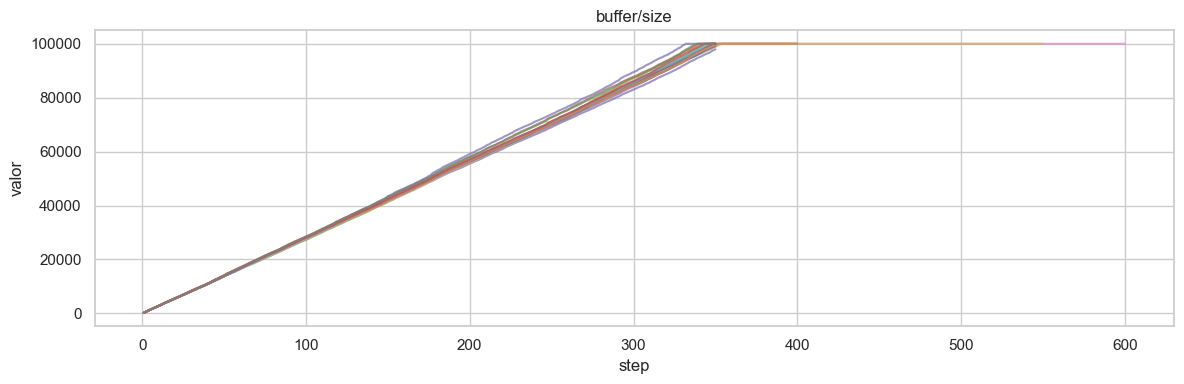

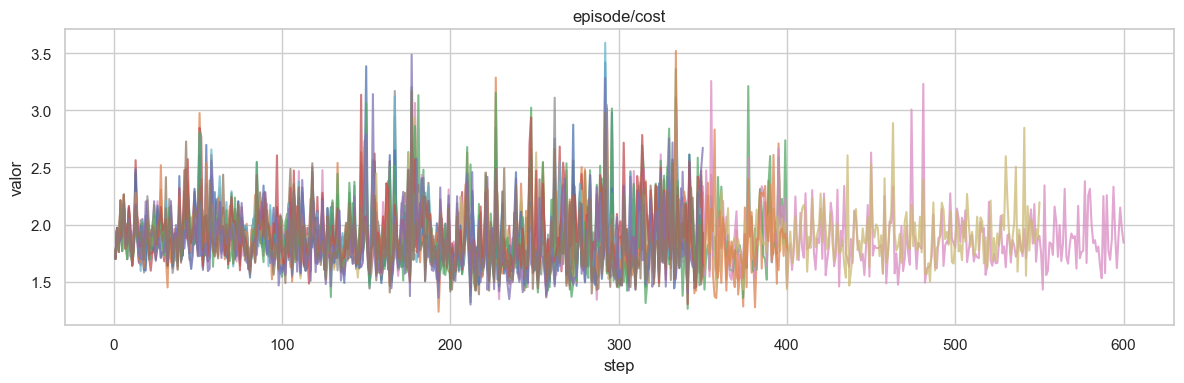

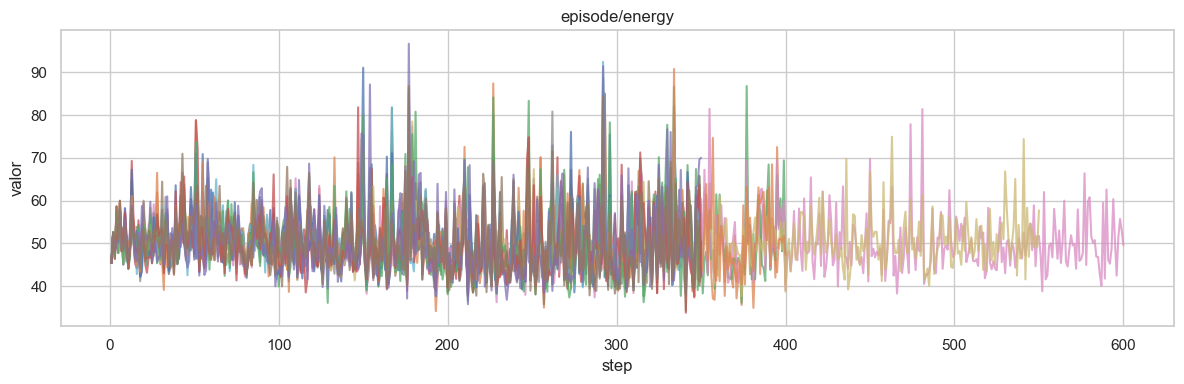

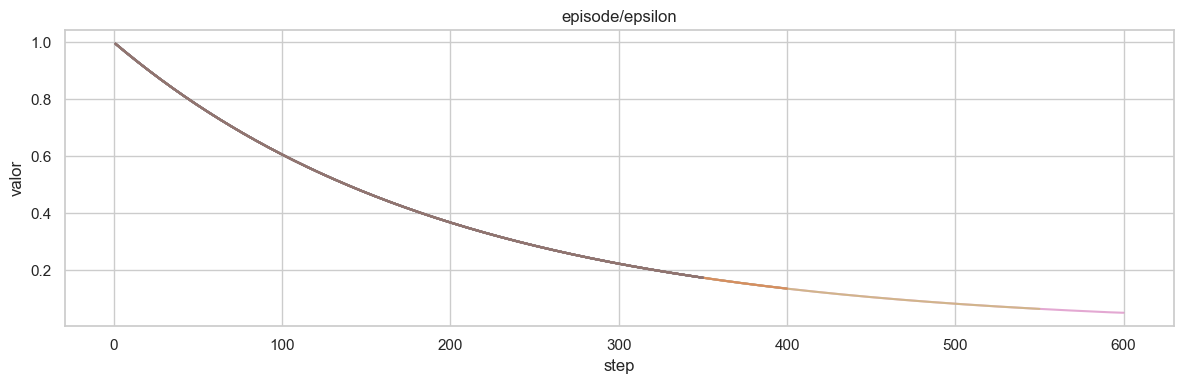

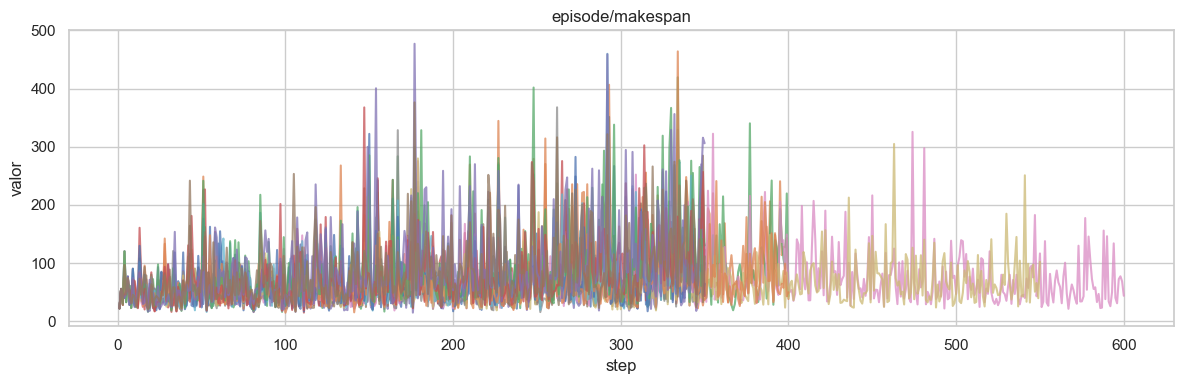

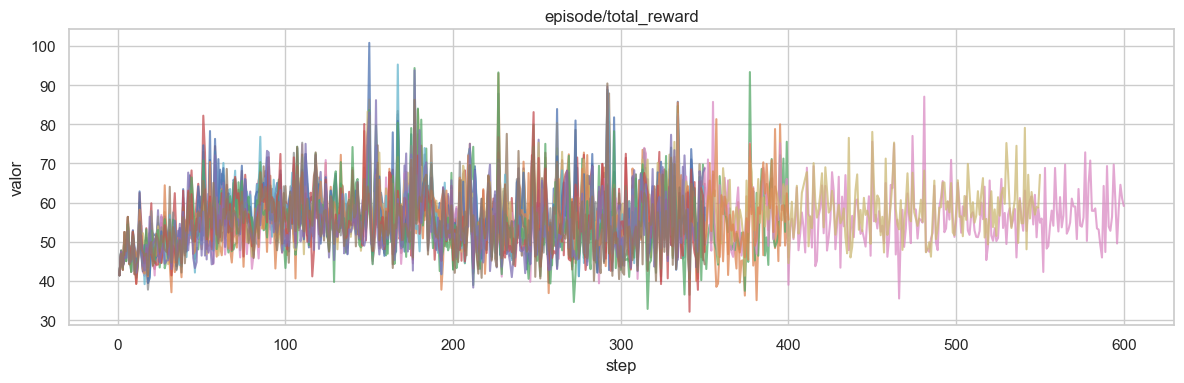

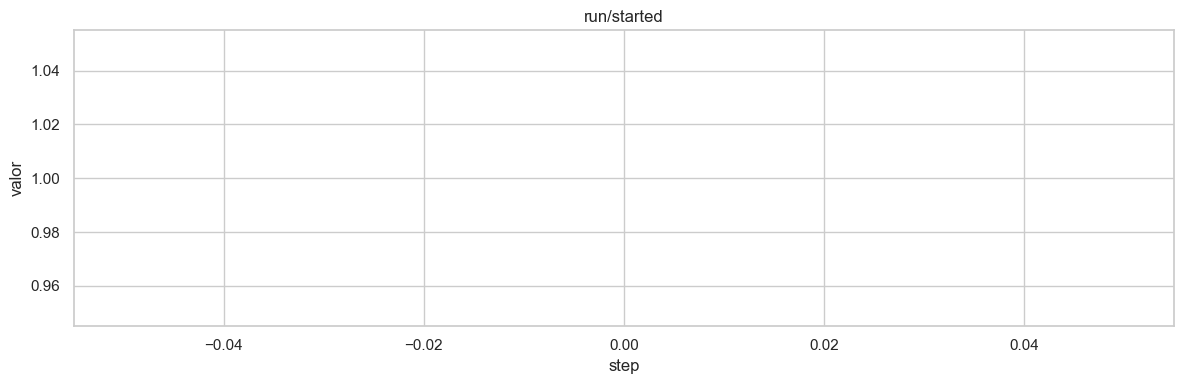

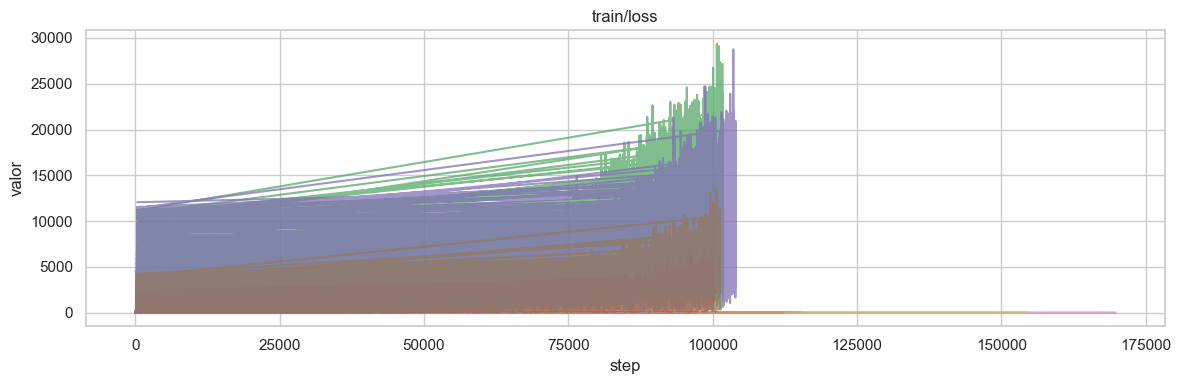

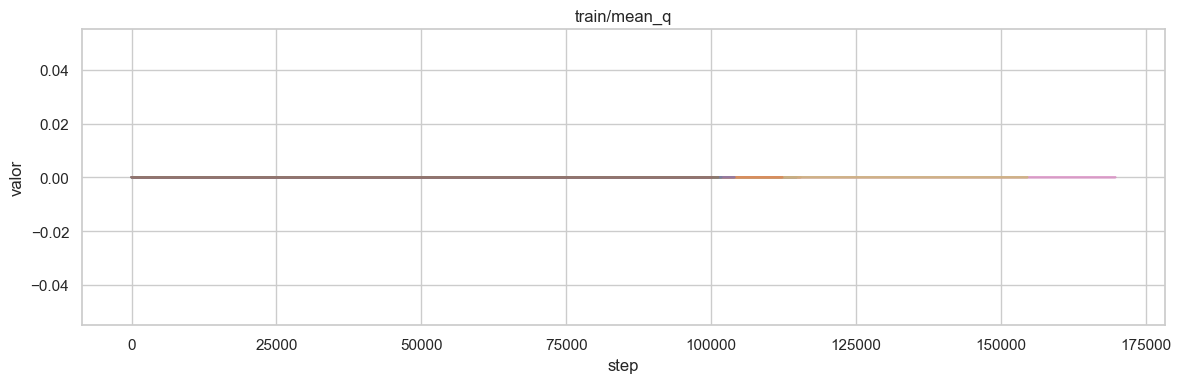

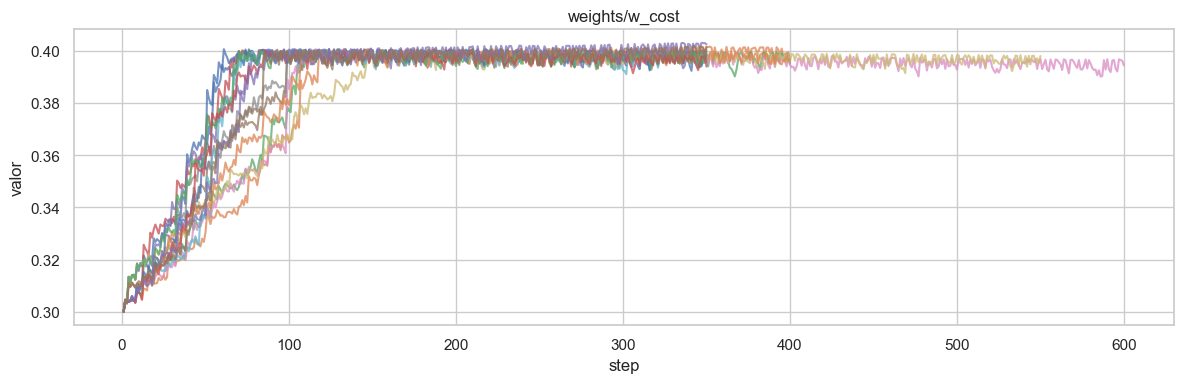

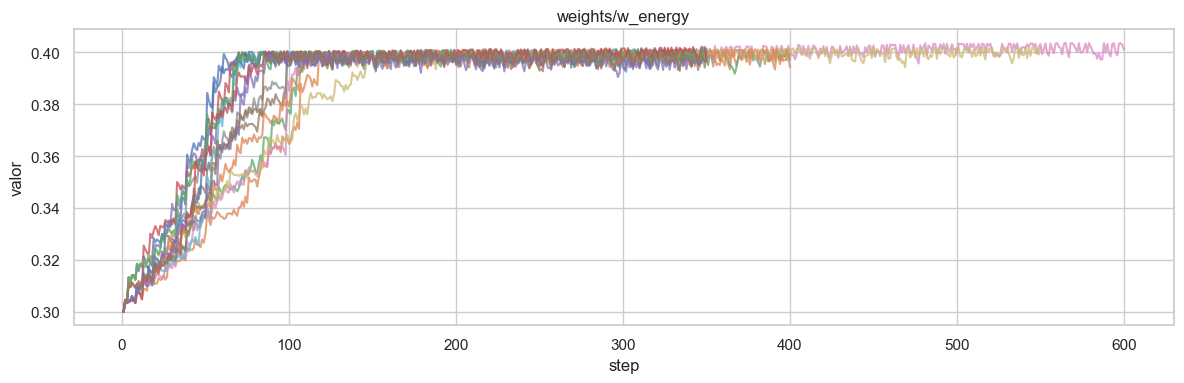

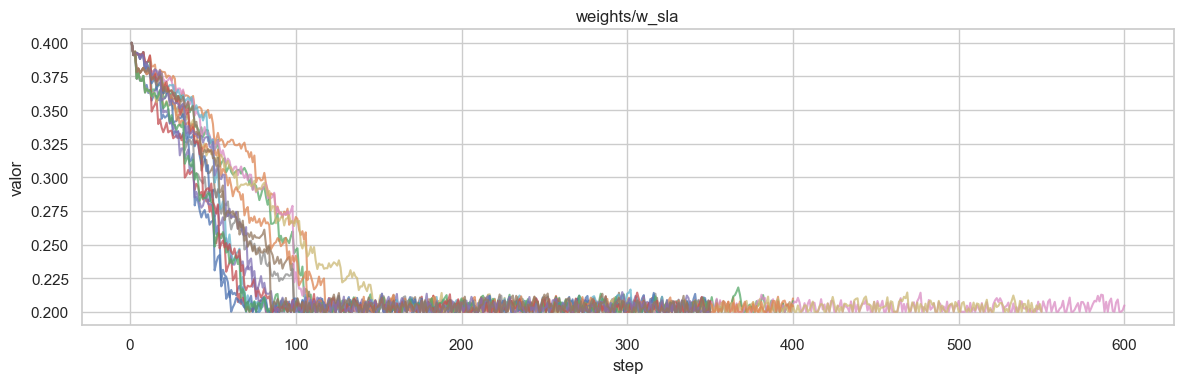

In [8]:
# Lectura de series escalares de TensorBoard
scalar_rows = []
tags_by_run = {}
for event_file in event_files:
    run_id = f"{event_file.parent.parent.name}/{event_file.parent.name}"
    try:
        accumulator = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
        accumulator.Reload()
        tags = accumulator.Tags().get("scalars", [])
        tags_by_run[run_id] = tags
        for tag in tags:
            scalar_rows.extend(
                {"run_id": run_id, "tag": tag, "step": event.step, "value": event.value}
                for event in accumulator.Scalars(tag)
            )
    except Exception as error:
        print(f"ADVERTENCIA: no se pudo leer {event_file}: {error}")

scalars = pd.DataFrame(scalar_rows)
all_tags = sorted(scalars["tag"].unique()) if not scalars.empty else []
print(f"Ejecuciones con eventos: {len(tags_by_run)}")
print("Etiquetas escalares encontradas:")
for tag in all_tags:
    print(f"- {tag}")

requested_tags = [
    "training/episode_reward", "training/average_loss", "training/epsilon",
    "agent/selected_vm", "simulation/makespan", "simulation/energy",
    "simulation/cost", "simulation/sla_violations", "workload/window_cloudlets",
    "workload/window_index",
]
for tag in requested_tags:
    if tag not in all_tags:
        print(f"ADVERTENCIA: etiqueta ausente, se omite: {tag}")

if not scalars.empty:
    for tag in all_tags:
        subset = scalars[scalars["tag"] == tag]
        plt.figure(figsize=(12, 4))
        for run_id, run_data in subset.groupby("run_id"):
            plt.plot(run_data["step"], run_data["value"], label=run_id, alpha=0.75)
        plt.title(tag)
        plt.xlabel("step")
        plt.ylabel("valor")
        if subset["run_id"].nunique() <= 12:
            plt.legend(fontsize=7)
        plt.tight_layout()
        plt.show()
else:
    print("No hay series escalares para graficar.")

# Inspección de checkpoints

Se inspeccionan metadatos de todos los `.pt` bajo `outputs/checkpoints/`. No se ejecuta inferencia porque aquí no se conoce la arquitectura exacta del agente.

In [9]:
# Metadatos y pesos de checkpoints
checkpoint_rows = []
for checkpoint_path in checkpoint_files:
    try:
        loaded = torch.load(checkpoint_path, map_location="cpu")
        keys = sorted(loaded.keys()) if isinstance(loaded, dict) else []
        checkpoint_rows.append({
            "name": checkpoint_path.name,
            "path": str(checkpoint_path),
            "size_mb": checkpoint_path.stat().st_size / (1024 ** 2),
            "modified": pd.Timestamp(checkpoint_path.stat().st_mtime, unit="s"),
            "keys": ", ".join(map(str, keys)),
            "epsilon": loaded.get("epsilon") if isinstance(loaded, dict) else None,
            "total_steps": loaded.get("total_steps") if isinstance(loaded, dict) else None,
        })
    except Exception as error:
        print(f"ADVERTENCIA: no se pudo cargar {checkpoint_path}: {error}")

checkpoints = pd.DataFrame(checkpoint_rows)
if not checkpoints.empty:
    display(checkpoints.sort_values(["path", "name"]))
else:
    print("No hay checkpoints .pt disponibles.")

,name,path,size_mb,modified,keys,epsilon,total_steps
0,checkpoint_final.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.034105,2026-08-31 02:26:56,"bits, epsilon, hidden_size, n_hidden_layers, o...",0.173013,98363
1,checkpoint_initial.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.017460,2026-08-31 02:21:00,"bits, epsilon, hidden_size, n_hidden_layers, o...",1.000000,0
2,checkpoint_final.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.010180,2026-08-31 02:07:14,"bits, epsilon, hidden_size, n_hidden_layers, o...",0.134658,115444
3,checkpoint_initial.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.005497,2026-08-31 01:59:50,"bits, epsilon, hidden_size, n_hidden_layers, o...",1.000000,0
4,checkpoint_final.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.013597,2026-08-31 02:14:34,"bits, epsilon, hidden_size, n_hidden_layers, o...",0.134658,114738
5,checkpoint_initial.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.007206,2026-08-31 02:07:28,"bits, epsilon, hidden_size, n_hidden_layers, o...",1.000000,0
6,checkpoint_final.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.020433,2026-08-31 02:20:46,"bits, epsilon, hidden_size, n_hidden_layers, o...",0.173013,98614
7,checkpoint_initial.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.010624,2026-08-31 02:14:48,"bits, epsilon, hidden_size, n_hidden_layers, o...",1.000000,0
8,checkpoint_final.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.033922,2026-08-31 02:51:52,"bits, epsilon, hidden_size, n_hidden_layers, o...",0.173013,95946
9,checkpoint_initial.pt,d:\Eracles\Markubes\Results3\outputs\checkpoin...,0.017399,2026-08-31 02:47:04,"bits, epsilon, hidden_size, n_hidden_layers, o...",1.000000,0


# Gráfico de decisión multicriterio

Este gráfico busca la configuración que combine **reward alto**, **SLA bajo**, **makespan bajo**, **latencia baja**, **throughput alto**, **tamaño razonable** y **coste computacional bajo**.

## Normalización matemática

Para cada métrica se toman todos los valores observados en el DataFrame. Sea $x_i$ el valor de una configuración y sean $x_{min}$ y $x_{max}$ el mínimo y el máximo observados.

### Métricas donde un valor alto es mejor

Se usa una normalización min-max directa:

$$
C_i = \frac{x_i - x_{min}}{x_{max} - x_{min}}
$$

Así:

- $C_i = 1$ corresponde al valor más alto observado.
- $C_i = 0$ corresponde al valor más bajo observado.
- Un valor intermedio indica la posición relativa entre ambos extremos.

En este análisis se aplica a:

- **Reward held-out:** $x_i = \text{eval\_mean\_reward}$.
- **Throughput:** $x_i = \text{throughput\_pps}$.

### Métricas donde un valor bajo es mejor

Primero se calcula la normalización directa y después se invierte:

$$
C_i = 1 - \frac{x_i - x_{min}}{x_{max} - x_{min}}
$$

Equivalentemente:

$$
C_i = \frac{x_{max} - x_i}{x_{max} - x_{min}}
$$

Así:

- $C_i = 1$ corresponde al valor más bajo observado.
- $C_i = 0$ corresponde al valor más alto observado.

En este análisis se aplica a:

- **SLA bajo:** $x_i = \text{eval\_sla\_rate}$.
- **Makespan bajo:** $x_i = \text{eval\_makespan}$.
- **Latencia baja:** $x_i = \text{latency\_p95\_ms}$.
- **Tamaño razonable:** $x_i = \text{packed\_size\_mb}$.
- **Coste computacional bajo:** $x_i = \text{flops}$.

### Caso de empate

Si todas las configuraciones tienen el mismo valor, entonces $x_{max} = x_{min}$ y la división no está definida. En ese caso se asigna:

$$
C_i = 1
$$

para todas las configuraciones, porque todas son igualmente buenas según esa métrica y el criterio no discrimina entre modelos. Esto ocurre actualmente con `eval_sla_rate = 0`.



# Pesos objetivos: entropía, entropía cruzada, KL y Jensen

Esta sección transforma las conveniencias $C_{ij}$ en distribuciones de probabilidad para medir cuánta información aporta cada métrica.

## Notación

- $i = 1, \ldots, n$ indexa configuraciones.
- $j = 1, \ldots, m$ indexa métricas.
- $C_{ij} \in [0,1]$ es la conveniencia normalizada de la configuración $i$ en la métrica $j$.
- $p_{ij}$ es la proporción de conveniencia de la configuración $i$ para la métrica $j$.
- $u_i = 1/n$ es la distribución uniforme de referencia.

La distribución se calcula como:

$$
p_{ij} = \frac{C_{ij}}{\sum_{r=1}^{n} C_{rj}}
$$

Si una columna no tiene masa positiva, se usa la distribución uniforme. Los ceros se sustituyen por un número muy pequeño solamente dentro de los logaritmos para evitar $\log(0)$.

## Entropía de Shannon

$$
H_j(p) = -\sum_{i=1}^{n} p_{ij}\log(p_{ij})
$$

Se normaliza por $\log(n)$:

$$
E_j = \frac{H_j(p)}{\log(n)}
$$

- $E_j \approx 1$: la métrica reparte su conveniencia de forma uniforme y discrimina poco.
- $E_j \approx 0$: la métrica concentra la conveniencia en pocas configuraciones y discrimina mucho.

## Entropía cruzada

La entropía cruzada de $p_j$ respecto a la distribución uniforme $u$ es:

$$
H(u,p_j) = -\sum_{i=1}^{n} u_i\log(p_{ij})
$$

Mide el coste de describir la distribución uniforme usando $p_j$. No debe confundirse con la entropía de Shannon ni usarse sola como peso: se reporta como diagnóstico de desajuste respecto a la referencia uniforme.

## Divergencia KL e información discriminativa

La divergencia de Kullback-Leibler de $p_j$ respecto a $u$ es:

$$
D_{KL}(p_j\|u) = \sum_{i=1}^{n}p_{ij}\log\left(\frac{p_{ij}}{u_i}\right)
$$

Como $u$ es uniforme:

$$
D_{KL}(p_j\|u) = \log(n) - H_j(p)
$$

Por tanto, una métrica constante tiene $D_{KL}=0$ y no aporta capacidad discriminativa. Los pesos objetivos se calculan como:

$$
 w_j = \frac{D_{KL}(p_j\|u)}{\sum_{k=1}^{m}D_{KL}(p_k\|u)}
$$

Estos pesos se derivan de los datos y no de una preferencia manual. Miden poder de discriminación, no importancia de negocio.

## Desigualdad de Jensen

La entropía de Shannon es cóncava. Para dos distribuciones $p$ y $q$, y $0 \leq \alpha \leq 1$:

$$
H(\alpha p + (1-\alpha)q)
\geq
\alpha H(p) + (1-\alpha)H(q)
$$

La celda calcula el margen de Jensen:

$$
J = H(\alpha p + (1-\alpha)q)
- \alpha H(p) - (1-\alpha)H(q)
$$

Debe cumplirse $J \geq 0$, salvo un error numérico muy pequeño. Este margen se interpreta como la diversidad adicional de la mezcla y sirve como validación matemática de la concavidad de la entropía.

In [11]:
# Normalización multicriterio de las métricas
# C_i ∈ [0, 1], donde 1 representa la mejor conveniencia.

if not results.empty:

    # (Etiqueta, columna original, orientación)
    metric_definitions = [
        ("Reward held-out", "eval_mean_reward", "max"),
        ("SLA", "eval_sla_rate", "min"),
        ("Makespan", "eval_makespan", "min"),
        ("Latencia P95", "latency_p95_ms", "min"),
        ("Throughput", "throughput_pps", "max"),
        ("Tamaño", "packed_size_mb", "min"),
        ("FLOPs", "flops", "min"),
    ]

    decision = results.copy()

    convenience_columns = []

    for label, column, direction in metric_definitions:

        values = pd.to_numeric(decision[column], errors="coerce")

        x_min = values.min()
        x_max = values.max()

        convenience_column = f"convenience_{column}"

        # Caso en que todas las configuraciones tienen el mismo valor
        if np.isclose(x_max, x_min):
            convenience = pd.Series(
                1.0,
                index=decision.index
            )

        else:
            if direction == "max":
                # Mayor valor = mejor
                convenience = (values - x_min) / (x_max - x_min)

            else:
                # Menor valor = mejor
                convenience = (x_max - values) / (x_max - x_min)

        decision[convenience_column] = convenience.clip(0, 1)

        convenience_columns.append(
            (label, convenience_column)
        )

    print("Matriz de conveniencia normalizada:")
    display(
        decision[
            ["config"] + [column for _, column in convenience_columns]
        ].style.format(precision=6)
    )

else:
    decision = pd.DataFrame()
    convenience_columns = []

Matriz de conveniencia normalizada:


,config,convenience_eval_mean_reward,convenience_eval_sla_rate,convenience_eval_makespan,convenience_latency_p95_ms,convenience_throughput_pps,convenience_packed_size_mb,convenience_flops
0,32 / cuda / 16,0.686058,1.000000,1.000000,0.545031,0.522567,0.901668,1.000000
1,32 / cuda / 32,0.869169,1.000000,0.000000,0.610037,0.533074,0.772858,0.857143
2,32 / cuda / 64,0.943380,1.000000,0.153933,0.342788,0.506924,0.515239,0.571429
3,32 / cuda / 128,0.813252,1.000000,0.900213,0.581145,0.532714,0.000000,0.000000
4,16 / cuda / 16,0.588872,1.000000,0.471623,0.234443,0.136563,0.967223,1.000000
5,16 / cuda / 32,0.769033,1.000000,0.380280,0.292227,0.136454,0.902818,0.857143
6,16 / cuda / 64,1.000000,1.000000,0.075728,0.234443,0.114905,0.774008,0.571429
7,16 / cuda / 128,0.953719,1.000000,0.064714,0.220223,0.124098,0.516389,0.000000
8,32 / cpu / 16,0.317183,1.000000,0.577247,0.967701,1.000000,0.901668,1.000000
9,32 / cpu / 32,0.737992,1.000000,0.234152,0.999513,0.979753,0.772858,0.857143


Información por métrica: entropía, entropía cruzada, KL y peso objetivo


,metric,entropy_nats,normalized_entropy,cross_entropy_uniform_nats,kl_to_uniform_nats,objective_weight
4,Throughput,2.322372,0.837619,5.369190,0.450216,0.279161
6,FLOPs,2.459678,0.887141,10.894553,0.312911,0.194023
3,Latencia P95,2.486998,0.896995,5.025570,0.285591,0.177084
2,Makespan,2.516783,0.907738,5.035292,0.255805,0.158615
5,Tamaño,2.616117,0.943565,6.836453,0.156472,0.097022
0,Reward held-out,2.620836,0.945267,4.912145,0.151753,0.094096
1,SLA,2.772589,1.000000,2.772589,0.000000,0.000000


Los pesos objetivos suman: 0.9999999999999998


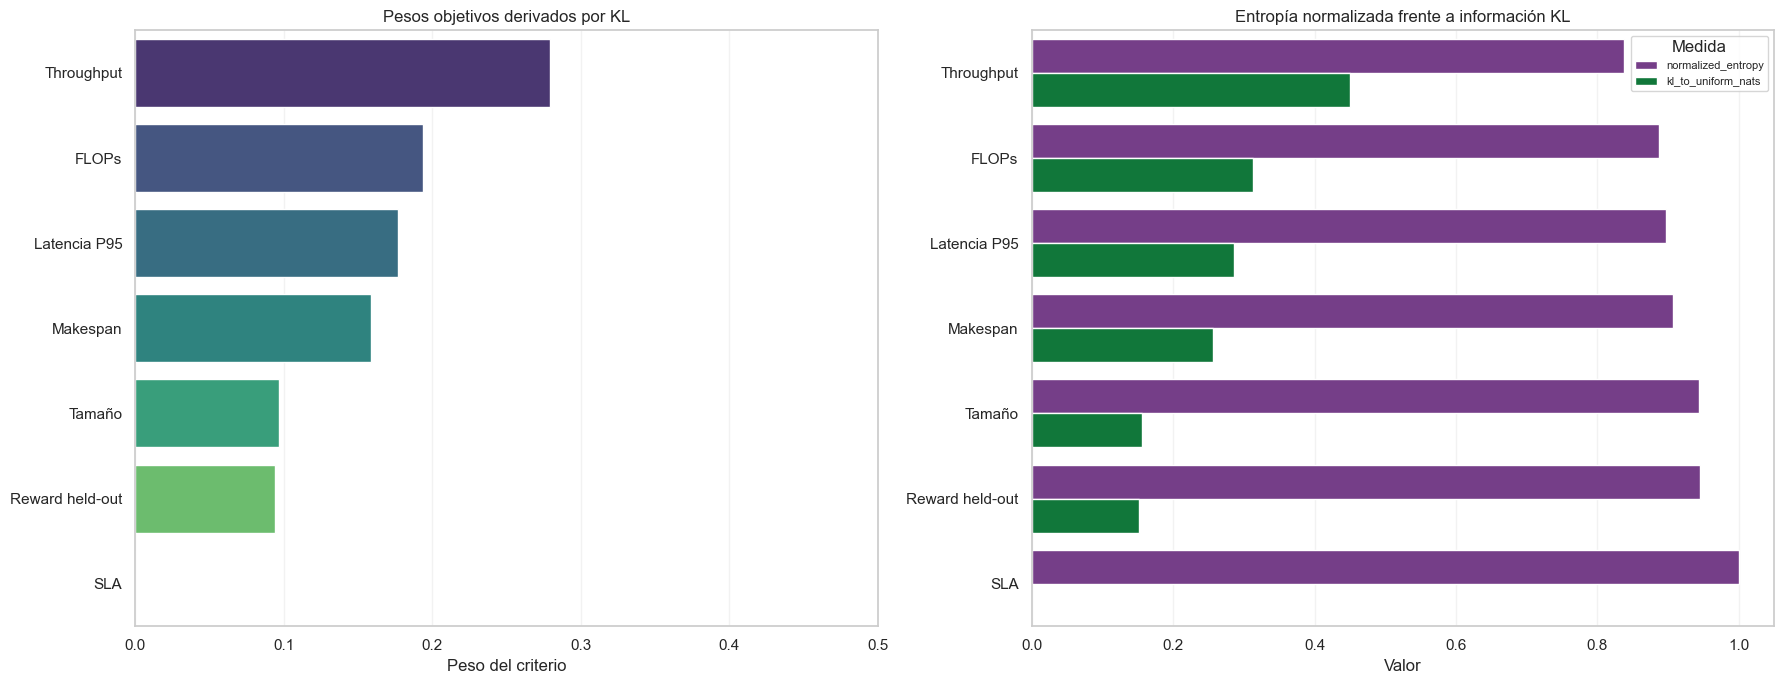

Ranking con pesos derivados por KL:


,config,entropy_weighted_score
8,32 / cpu / 16,0.853435
9,32 / cpu / 32,0.798378
0,32 / cuda / 16,0.747071
10,32 / cpu / 64,0.718895
11,32 / cpu / 128,0.601067
1,32 / cuda / 32,0.579916
4,16 / cuda / 16,0.497721
5,16 / cuda / 32,0.476421
2,32 / cuda / 64,0.476259
3,32 / cuda / 128,0.470935


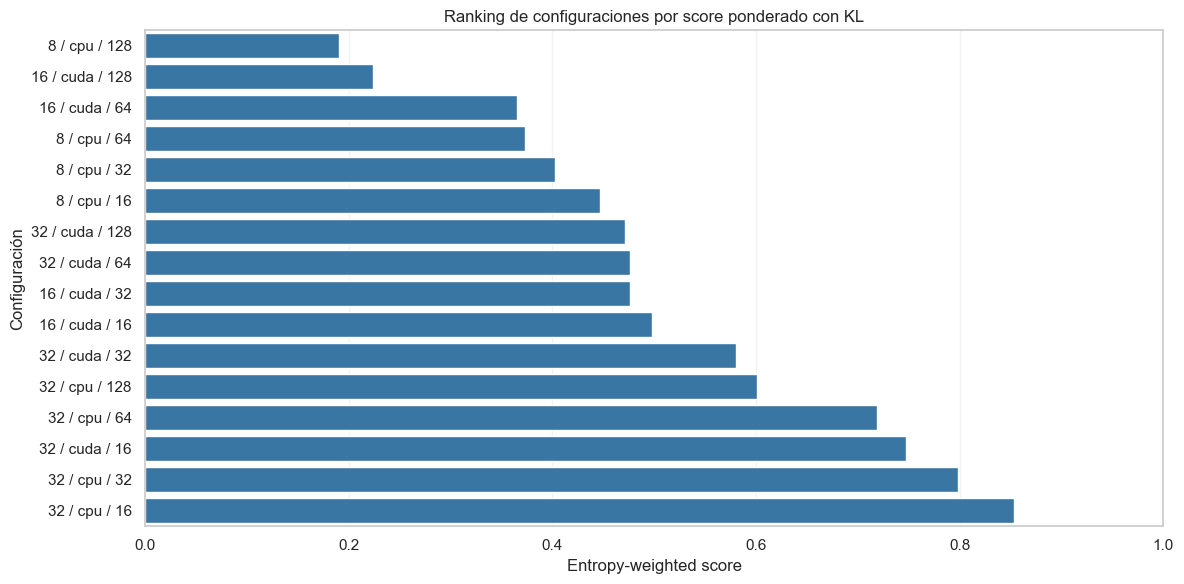

Jensen: margen mínimo observado = 0.00302921292822
Jensen se verifica numéricamente: True


,config_a,config_b,alpha,jensen_gap
110,32 / cpu / 128,8 / cpu / 16,0.50000000,0.30061549
113,32 / cpu / 128,8 / cpu / 128,0.50000000,0.29801374
28,32 / cuda / 32,8 / cpu / 128,0.50000000,0.28822429
112,32 / cpu / 128,8 / cpu / 64,0.50000000,0.28715886
50,32 / cuda / 128,8 / cpu / 16,0.50000000,0.26951393
111,32 / cpu / 128,8 / cpu / 32,0.50000000,0.26308697
109,32 / cpu / 64,8 / cpu / 128,0.50000000,0.26308160
104,32 / cpu / 32,8 / cpu / 128,0.50000000,0.25844272
53,32 / cuda / 128,8 / cpu / 128,0.50000000,0.25231472
41,32 / cuda / 64,8 / cpu / 128,0.50000000,0.24661311


In [12]:
# Cálculo objetivo de entropía, entropía cruzada, KL y Jensen
if not results.empty:
    metric_labels = [label for label, _ in convenience_columns]
    metric_columns = [column for _, column in convenience_columns]
    convenience_matrix = decision[metric_columns].astype(float).clip(lower=0)
    n_configurations = len(convenience_matrix)
    epsilon = np.finfo(float).eps
    uniform = np.full(n_configurations, 1.0 / n_configurations)

    probability_matrix = pd.DataFrame(index=decision.index, columns=metric_columns, dtype=float)
    metric_rows = []
    for label, column in zip(metric_labels, metric_columns):
        values = convenience_matrix[column].to_numpy()
        total = values.sum()
        probabilities = uniform.copy() if total <= 0 else values / total
        safe_probabilities = np.clip(probabilities, epsilon, 1.0)
        entropy_nats = -np.sum(probabilities * np.log(safe_probabilities))
        normalized_entropy = entropy_nats / np.log(n_configurations) if n_configurations > 1 else 0.0
        cross_entropy_nats = -np.sum(uniform * np.log(safe_probabilities))
        kl_nats = np.sum(probabilities * np.log(safe_probabilities / uniform))
        probability_matrix[column] = probabilities
        metric_rows.append({
            "metric": label,
            "entropy_nats": entropy_nats,
            "normalized_entropy": normalized_entropy,
            "cross_entropy_uniform_nats": cross_entropy_nats,
            "kl_to_uniform_nats": max(0.0, kl_nats),
        })

    information_table = pd.DataFrame(metric_rows)
    total_kl = information_table["kl_to_uniform_nats"].sum()
    if total_kl > 0:
        information_table["objective_weight"] = information_table["kl_to_uniform_nats"] / total_kl
    else:
        information_table["objective_weight"] = 1.0 / len(information_table)

    objective_weights = dict(zip(information_table["metric"], information_table["objective_weight"]))
    entropy_score = sum(
        objective_weights[label] * decision[column]
        for label, column in zip(metric_labels, metric_columns)
    )
    decision["entropy_weighted_score"] = entropy_score

    ranked_information = information_table.sort_values("objective_weight", ascending=False)
    print("Información por métrica: entropía, entropía cruzada, KL y peso objetivo")
    display(ranked_information.style.format(precision=6))
    print("Los pesos objetivos suman:", information_table["objective_weight"].sum())

    # Gráficos de lectura rápida para acompañar la tabla de información.
    figure, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.barplot(
        data=ranked_information,
        x="objective_weight",
        y="metric",
        hue="metric",
        palette="viridis",
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title("Pesos objetivos derivados por KL")
    axes[0].set_xlabel("Peso del criterio")
    axes[0].set_ylabel("")
    axes[0].set_xlim(0, max(0.5, ranked_information["objective_weight"].max() * 1.15))
    axes[0].grid(axis="x", alpha=0.25)

    information_plot = ranked_information.melt(
        id_vars="metric",
        value_vars=["normalized_entropy", "kl_to_uniform_nats"],
        var_name="measure",
        value_name="value",
    )
    sns.barplot(
        data=information_plot,
        x="value",
        y="metric",
        hue="measure",
        palette={"normalized_entropy": "#7b3294", "kl_to_uniform_nats": "#008837"},
        ax=axes[1],
    )
    axes[1].set_title("Entropía normalizada frente a información KL")
    axes[1].set_xlabel("Valor")
    axes[1].set_ylabel("")
    axes[1].legend(title="Medida", fontsize=8)
    axes[1].grid(axis="x", alpha=0.25)
    figure.tight_layout()
    plt.show()

    entropy_ranking = decision[["config", "entropy_weighted_score"]].sort_values(
        "entropy_weighted_score", ascending=False
    )
    print("Ranking con pesos derivados por KL:")
    display(entropy_ranking.style.format(precision=6))

    figure, axis = plt.subplots(figsize=(12, max(6, len(entropy_ranking) * 0.35)))
    top_ranking = entropy_ranking.sort_values("entropy_weighted_score", ascending=True)
    sns.barplot(
        data=top_ranking,
        x="entropy_weighted_score",
        y="config",
        color="#2878b5",
        ax=axis,
    )
    axis.set_title("Ranking de configuraciones por score ponderado con KL")
    axis.set_xlabel("Entropy-weighted score")
    axis.set_ylabel("Configuración")
    axis.set_xlim(0, 1)
    axis.grid(axis="x", alpha=0.25)
    figure.tight_layout()
    plt.show()

    # Jensen sobre perfiles de cada configuración a través de las siete métricas.
    profile_matrix = decision[metric_columns].to_numpy(dtype=float)
    profile_totals = profile_matrix.sum(axis=1, keepdims=True)
    profile_probabilities = np.divide(
        profile_matrix,
        profile_totals,
        out=np.full_like(profile_matrix, 1.0 / len(metric_columns)),
        where=profile_totals > 0,
    )

    def shannon_entropy(probabilities):
        safe_values = np.clip(probabilities, epsilon, 1.0)
        return float(-np.sum(probabilities * np.log(safe_values)))

    alpha = 0.5
    jensen_rows = []
    for first in range(len(profile_probabilities)):
        for second in range(first + 1, len(profile_probabilities)):
            first_profile = profile_probabilities[first]
            second_profile = profile_probabilities[second]
            mixture = alpha * first_profile + (1 - alpha) * second_profile
            jensen_gap = shannon_entropy(mixture) - (
                alpha * shannon_entropy(first_profile)
                + (1 - alpha) * shannon_entropy(second_profile)
            )
            jensen_rows.append({
                "config_a": decision.iloc[first]["config"],
                "config_b": decision.iloc[second]["config"],
                "alpha": alpha,
                "jensen_gap": jensen_gap,
            })

    jensen_table = pd.DataFrame(jensen_rows)
    minimum_gap = jensen_table["jensen_gap"].min() if not jensen_table.empty else 0.0
    print(f"Jensen: margen mínimo observado = {minimum_gap:.12g}")
    print("Jensen se verifica numéricamente:", minimum_gap >= -1e-12)
    display(jensen_table.sort_values("jensen_gap", ascending=False).head(10).style.format(precision=8))
else:
    print("Sin datos: no se pueden calcular las métricas de información.")

# Ecuación final del score y heatmap de contribuciones

La ecuación final usa los pesos objetivos derivados mediante la divergencia KL:

$$
S_i = \sum_{j=1}^{m} w_j C_{ij}
$$

donde $C_{ij}$ es la conveniencia normalizada de la configuración $i$ en el criterio $j$, y $w_j$ es el coeficiente obtenido a partir de:

$$
w_j = \frac{D_{KL}(p_j\|u)}{\sum_{k=1}^{m}D_{KL}(p_k\|u)}
$$

La siguiente celda imprime la ecuación con sus coeficientes numéricos y construye un heatmap de las contribuciones:

$$
\text{contribución}_{ij} = w_j C_{ij}
$$

Por tanto, la suma de una fila del heatmap es el score multicriterio de esa configuración.

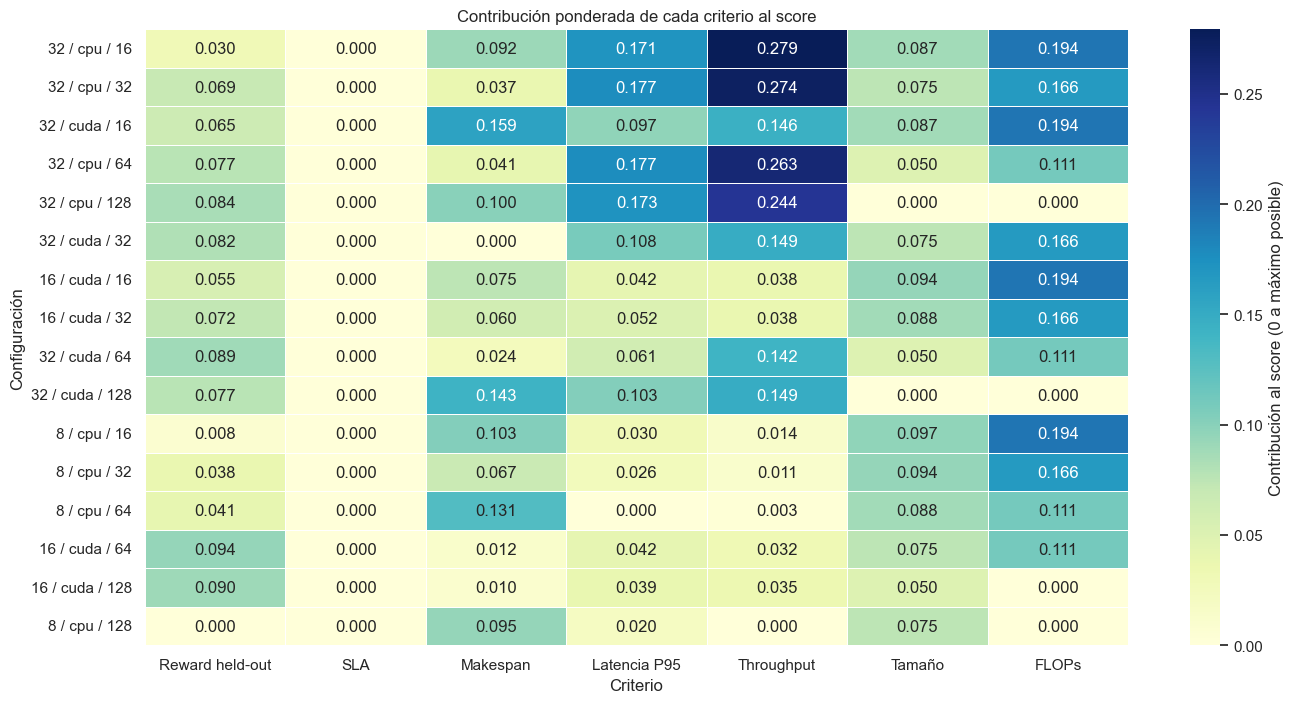

Tabla de contribuciones; la suma de cada fila es el score:


,Reward held-out,SLA,Makespan,Latencia P95,Throughput,Tamaño,FLOPs,Score total
config,,,,,,,,
32 / cpu / 16,0.029846,0.000000,0.091560,0.171364,0.279161,0.087481,0.194023,0.853435
32 / cpu / 32,0.069442,0.000000,0.037140,0.176997,0.273509,0.074984,0.166306,0.798378
32 / cuda / 16,0.064555,0.000000,0.158615,0.096516,0.145880,0.087481,0.194023,0.747071
32 / cpu / 64,0.077098,0.000000,0.041206,0.177084,0.262648,0.049989,0.110870,0.718895
32 / cpu / 128,0.084069,0.000000,0.099873,0.173263,0.243862,0.000000,0.000000,0.601067
32 / cuda / 32,0.081785,0.000000,0.000000,0.108028,0.148813,0.074984,0.166306,0.579916
16 / cuda / 16,0.055410,0.000000,0.074806,0.041516,0.038123,0.093842,0.194023,0.497721
16 / cuda / 32,0.072363,0.000000,0.060318,0.051749,0.038093,0.087593,0.166306,0.476421
32 / cuda / 64,0.088768,0.000000,0.024416,0.060702,0.141513,0.049989,0.110870,0.476259


In [13]:
# Ecuación con coeficientes KL y heatmap de contribuciones por configuración
if not results.empty and "objective_weights" in globals():
    equation_terms = []
    contribution_columns = []
    contribution_labels = []
    for label, column in zip(metric_labels, metric_columns):
        weight = objective_weights[label]
        equation_terms.append(f"({weight:.6f})*C_{label.replace(' ', '_')}")
        contribution_column = f"contribution_{column}"
        decision[contribution_column] = weight * decision[column]
        contribution_columns.append(contribution_column)
        contribution_labels.append(label)

    equation = "S_i = " + " + ".join(equation_terms)
 

    contribution_data = decision.set_index("config")[contribution_columns].copy()
    contribution_data.columns = contribution_labels
    contribution_data["Score total"] = contribution_data.sum(axis=1)
    contribution_data = contribution_data.sort_values("Score total", ascending=False)

    # La escala absoluta permite comparar colores entre criterios: 0 es ausencia
    # de contribución y el máximo es el mayor peso posible del score.
    max_possible_contribution = max(objective_weights.values())
    figure, axis = plt.subplots(figsize=(14, max(7, len(contribution_data) * 0.45)))
    sns.heatmap(
        contribution_data[contribution_labels],
        ax=axis,
        cmap="YlGnBu",
        vmin=0,
        vmax=max_possible_contribution,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        cbar_kws={"label": "Contribución al score (0 a máximo posible)"},
    )
    axis.set_title("Contribución ponderada de cada criterio al score")
    axis.set_xlabel("Criterio")
    axis.set_ylabel("Configuración")
    figure.tight_layout()
    plt.show()

    print("Tabla de contribuciones; la suma de cada fila es el score:")
    display(contribution_data.style.format(precision=6))
else:
    print("Sin datos o sin pesos KL: no se puede construir la ecuación final.")

# Conclusiones y límites de interpretación

El veredicto final debe separar tres preguntas:

1. ¿Qué configuración maximiza calidad held-out?
2. ¿Qué configuración ofrece el mejor compromiso operativo según el score?
3. ¿Qué configuración cumple las restricciones reales del despliegue?

El score es relativo a las configuraciones observadas. No convierte el análisis en una prueba de superioridad universal. CPU y CUDA deben compararse por separado cuando el hardware de producción esté fijado, y throughput y latencia solo son comparables si comparten batch size, número de muestras, warmup y protocolo de medición.

In [ ]:
# Resumen automático del informe
if not results.empty:
    best_reward = results.loc[results["eval_mean_reward"].idxmax()]
    best_latency = results.loc[results["latency_p95_ms"].idxmin()]
    best_throughput = results.loc[results["throughput_pps"].idxmax()]
    best_size = results.loc[results["packed_size_mb"].idxmin()]
    best_score = decision.sort_values("entropy_weighted_score", ascending=False).iloc[0]

    print(f"Configuraciones analizadas: {len(results)}")
    print(f"Mejor reward held-out: {best_reward['config']} ({best_reward['eval_mean_reward']:.3f})")
    print(f"Menor latencia P95: {best_latency['config']} ({best_latency['latency_p95_ms']:.4f} ms)")
    print(f"Mayor throughput: {best_throughput['config']} ({best_throughput['throughput_pps']:.3f} pps)")
    print(f"Menor tamaño: {best_size['config']} ({best_size['packed_size_mb']:.4f} MB)")
    print(f"Recomendación por score KL: {best_score['config']} ({best_score['entropy_weighted_score']:.6f})")
    print(f"SLA: {results['eval_sla_rate'].eq(0).sum()} de {len(results)} configuraciones tienen tasa cero.")
else:
    print("No hay datos para generar conclusiones.")

Configuraciones analizadas: 17
Mejor reward held-out: 8 / cpu / 2048 (19.464)
Menor latencia P95: 32 / cpu / 512 (0.0450 ms)
Mayor throughput: 32 / cpu / 256 (1236937.864 pps)
Menor tamaño: 8 / cpu / 256 (0.0694 MB)
Recomendación por score KL: 32 / cpu / 256 (0.944164)
SLA: 17 de 17 configuraciones tienen tasa cero.


In [14]:
print("\n" + "=" * 60)
print("NUEVOS PESOS OBJETIVOS DERIVADOS POR KL")
print("=" * 60)

for metric, weight in objective_weights.items():
    print(f"{metric:<25} = {weight:.9f}")

print("-" * 60)
print(f"{'SUMA':<25} = {sum(objective_weights.values()):.9f}")
print("=" * 60)


NUEVOS PESOS OBJETIVOS DERIVADOS POR KL
Reward held-out           = 0.094095962
SLA                       = 0.000000000
Makespan                  = 0.158614559
Latencia P95              = 0.177083527
Throughput                = 0.279160882
Tamaño                    = 0.097021817
FLOPs                     = 0.194023252
------------------------------------------------------------
SUMA                      = 1.000000000


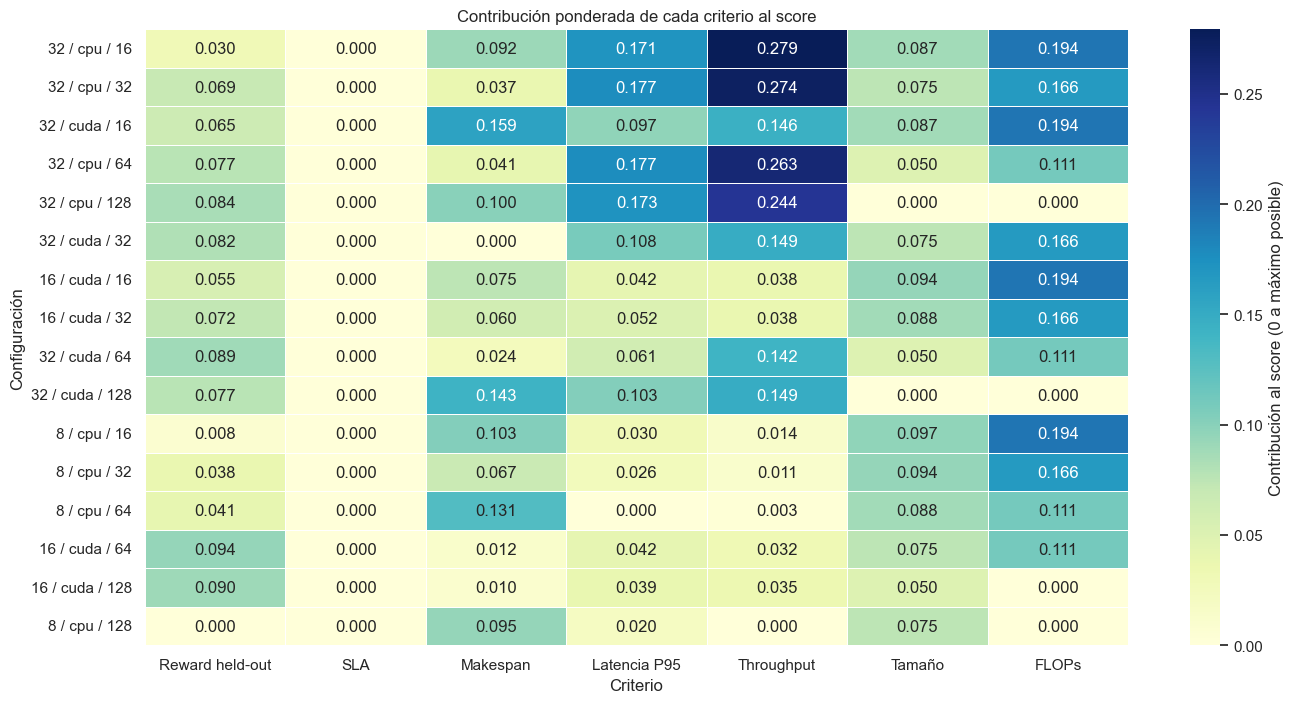

Tabla de contribuciones; la suma de cada fila es el score:


,Reward held-out,SLA,Makespan,Latencia P95,Throughput,Tamaño,FLOPs,Score total
config,,,,,,,,
32 / cpu / 16,0.029846,0.000000,0.091560,0.171364,0.279161,0.087481,0.194023,0.853435
32 / cpu / 32,0.069442,0.000000,0.037140,0.176997,0.273509,0.074984,0.166306,0.798378
32 / cuda / 16,0.064555,0.000000,0.158615,0.096516,0.145880,0.087481,0.194023,0.747071
32 / cpu / 64,0.077098,0.000000,0.041206,0.177084,0.262648,0.049989,0.110870,0.718895
32 / cpu / 128,0.084069,0.000000,0.099873,0.173263,0.243862,0.000000,0.000000,0.601067
32 / cuda / 32,0.081785,0.000000,0.000000,0.108028,0.148813,0.074984,0.166306,0.579916
16 / cuda / 16,0.055410,0.000000,0.074806,0.041516,0.038123,0.093842,0.194023,0.497721
16 / cuda / 32,0.072363,0.000000,0.060318,0.051749,0.038093,0.087593,0.166306,0.476421
32 / cuda / 64,0.088768,0.000000,0.024416,0.060702,0.141513,0.049989,0.110870,0.476259


In [16]:
# Ecuación con coeficientes KL y heatmap de contribuciones por configuración
if not results.empty and "objective_weights" in globals():
    equation_terms = []
    contribution_columns = []
    contribution_labels = []
    for label, column in zip(metric_labels, metric_columns):
        weight = objective_weights[label]
        equation_terms.append(f"({weight:.6f})*C_{label.replace(' ', '_')}")
        contribution_column = f"contribution_{column}"
        decision[contribution_column] = weight * decision[column]
        contribution_columns.append(contribution_column)
        contribution_labels.append(label)

    equation = "S_i = " + " + ".join(equation_terms)

    contribution_data = decision.set_index("config")[contribution_columns].copy()
    contribution_data.columns = contribution_labels
    contribution_data["Score total"] = contribution_data.sum(axis=1)
    contribution_data = contribution_data.sort_values("Score total", ascending=False)

    # ---------------------------------------------------------
    # GUARDAR EN ARCHIVO CSV
    # ---------------------------------------------------------
    contribution_data.to_csv("contribuciones_configuracion.csv", index=True, encoding="utf-8-sig")

    # La escala absoluta permite comparar colores entre criterios: 0 es ausencia
    # de contribución y el máximo es el mayor peso posible del score.
    max_possible_contribution = max(objective_weights.values())
    figure, axis = plt.subplots(figsize=(14, max(7, len(contribution_data) * 0.45)))
    sns.heatmap(
        contribution_data[contribution_labels],
        ax=axis,
        cmap="YlGnBu",
        vmin=0,
        vmax=max_possible_contribution,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        cbar_kws={"label": "Contribución al score (0 a máximo posible)"},
    )
    axis.set_title("Contribución ponderada de cada criterio al score")
    axis.set_xlabel("Criterio")
    axis.set_ylabel("Configuración")
    figure.tight_layout()
    plt.show()

    print("Tabla de contribuciones; la suma de cada fila es el score:")
    display(contribution_data.style.format(precision=6))
else:
    print("Sin datos o sin pesos KL: no se puede construir la ecuación final.")